<a href="https://colab.research.google.com/github/saskiaalifah/SaskiaAlifah_2411531002_BigData26/blob/main/Praktikum3/BD_P03_2411531002_SaskiaAlifah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 3: PENGUMPULAN & PRA-PEMROSESAN DATA UNTUK BIG DATA


## K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1

**Keputusan:** fungsi `ukur()` (pengukur waktu dan memori) dipakai kembali dari Praktikum 1, dan struktur baru `lineage` ditambahkan untuk mencatat asal-usul setiap sumber data. Direktori `lapisan_mentah/` menampung data mentah (tidak pernah ditimpa) dan `lapisan_terkurasi/` menampung hasil olahan, mengikuti arsitektur medallion pada Bagian G.1. Notebook dijalankan di Google Colab dengan Google Drive terpasang, sehingga artefak akhir disimpan ke `MyDrive/BigData/Praktikum3`.

In [1]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil
for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")
from google.colab import drive
drive.mount("/content/drive")
DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)
# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []
def rss_mb():
    return proses.memory_info().rss / 1024**2
def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil
# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []
def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Penjelasan kode.** Sel ini mencetak versi enam pustaka utama, memasang Google Drive, membuat tiga direktori kerja (`lapisan_mentah`, `lapisan_terkurasi`, dan folder simpan di Drive), lalu mendefinisikan `ukur()` untuk mencatat waktu dan perubahan memori tiap langkah ke list `catatan`, serta `catat_sumber()` untuk mencatat asal-usul data ke list `lineage`.

**Interpretasi hasil.** Keenam pustaka terpasang: pandas 2.2.3, numpy 2.1.3, pyarrow 23.0.1, requests 2.32.4, scikit-learn 1.6.1, dan SQLAlchemy 2.0.54. Seluruhnya memenuhi versi rekomendasi modul (pandas 2.2 ke atas, pyarrow 14 ke atas, scikit-learn 1.4 ke atas, SQLAlchemy 2.0 ke atas), sehingga `sparse_output` pada `OneHotEncoder` dan `merge(validate=...)` aman dipakai. Pesan `Drive already mounted` berarti Drive sudah terpasang sejak sesi sebelumnya, jadi tidak perlu dipasang ulang. `catatan` dan `lineage` masih kosong dan akan terisi sepanjang notebook, lalu disimpan sebagai artefak pada K-10.

## K-2. Akuisisi 1: Unduhan Berkala yang Tahan Gagal

**Keputusan:** data trip dan tabel zona diambil dari sumber aslinya (TLC), bukan data sintetis. Fungsi `unduh_aman()` memakai retry berjeda meningkat dan penulisan atomik (`.part` lalu `os.replace`) seperti modul. Satu perubahan dari modul: isi respons ditulis lewat `iter_content()`, bukan `shutil.copyfileobj(r.raw, ...)`, karena `r.raw` mengembalikan byte apa adanya tanpa dekompresi gzip, yang kemungkinan menjadi penyebab berkas CSV zona sempat terbaca sebagai biner atau korup. Berkas zona lama yang rusak dihapus lebih dulu agar diunduh ulang.

In [2]:
import requests, shutil, os, time
import pandas as pd

# Hapus file zona yang biner/korup dari percobaan sebelumnya
if 'DIR_MENTAH' in locals():
    file_zona_bermasalah = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")
    if os.path.exists(file_zona_bermasalah):
        os.remove(file_zona_bermasalah)
        print(f"Berkas korup lama dihapus: {file_zona_bermasalah}")

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)

            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")

            os.replace(sementara, tujuan) # atomik
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i) # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)

    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

# Definisi URL dan Path Tujuan
URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

# Eksekusi Unduhan dengan pencatatan waktu
ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

# Cek ukuran file yang berhasil diunduh
for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

# Membaca Data ke dalam Pandas DataFrame
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

# Mencatat asal-usul (lineage)
catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")

zona.head()

Berkas korup lama dihapus: /content/lapisan_mentah/taxi_zone_lookup.csv
cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s
[unduh zona] 0.09 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 2.54 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


**Penjelasan kode.** Sel ini menghapus berkas zona lama yang korup, mendefinisikan `unduh_aman()` (cache, retry dengan exponential backoff, penulisan atomik), mengunduh dua berkas ke `lapisan_mentah/`, lalu membaca Parquet trip (hanya 10 kolom pada `KOLOM`, termasuk `PULocationID` dan `DOLocationID` sebagai kunci join K-8) dan CSV zona. Setiap sumber dicatat ke `lineage`.

**Interpretasi hasil.** Berkas trip sudah ada di cache dari sesi sebelumnya (`cache ditemukan`, 0,00 s), sedangkan berkas zona diunduh ulang dalam 0,03 s. Ukuran berkas: trip 45,46 MB dan zona 0,01 MB. Pembacaan Parquet memakan 0,89 s dan menghasilkan **3.066.766 baris** trip (Januari 2023, data asli TLC) serta **265 baris** zona (LocationID 1 sampai 265; menurut tabel lookup TLC, kode 264 dan 265 adalah kode khusus, bukan zona fisik biasa). `zona.head()` menampilkan lima zona pertama beserta borough dan service_zone-nya. Kedua angka tersebut juga tercatat di `lineage`.

## K-3. Akuisisi 2: Memanggil API JSON

**Keputusan:** cuaca diambil langsung dari API Open-Meteo untuk 1 sampai 31 Januari 2023 dengan zona waktu `America/New_York`, sama dengan zona waktu stempel waktu trip sehingga join per jam pada K-8 tidak bergeser. `ambil_cuaca()` mengirim parameter sebagai `dict`, memvalidasi kunci `hourly` pada respons, dan mengulang permintaan hanya untuk status 429/500/502/503. Jalur cadangan sintetis (K-4) disiapkan oleh modul tetapi tidak dipakai karena API dapat dijangkau.

In [3]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:  # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):  # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()  # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m": "suhu_c",
                              "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.47 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


**Penjelasan kode.** `ambil_cuaca()` memanggil API dengan retry, lalu bagian `hourly` respons diubah menjadi DataFrame. Kolom `time` dikonversi ke datetime dan seluruh kolom diganti nama menjadi `jam_mulai`, `suhu_c`, dan `hujan_mm` agar bisa dijadikan kunci join pada K-8. Sumber dicatat ke `lineage`.

**Interpretasi hasil.** Panggilan API berhasil dalam 0,42 s dan mengembalikan **744 baris**, sama dengan 31 hari x 24 jam, jadi tidak ada jam yang hilang. Lima baris pertama (1 Januari 2023, pukul 00:00 sampai 04:00) menunjukkan suhu sekitar 10 sampai 11 derajat Celsius dengan hujan 1,0 mm pada dua jam pertama, 0,1 mm pada jam ketiga, lalu berhenti. Karena cuaca lengkap satu baris per jam, tingkat rinciannya siap disamakan dengan `jam_mulai` trip pada join K-8.

## K-5. Akuisisi 3: Basis Data SQLite dengan Pemuatan Bertahap

**Keputusan:** memakai `SQLAlchemy` (bukan koneksi `sqlite3` mentah) agar bebas peringatan pada pandas 2.0 ke atas, sesuai anjuran Bagian H modul. Tabel `trip_operasional` diisi dari 300.000 baris pertama `trip` (mensimulasikan sistem operasional), ditulis bertahap dengan `chunksize=50_000`.

In [4]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
FROM trip_operasional
WHERE total_amount > 0
GROUP BY payment_type
ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


**Penjelasan kode.** Sel ini membuat basis data SQLite `operasional.db` berisi dua tabel: `tarif_referensi` (tabel dimensi jenis pembayaran) dan `trip_operasional` (300.000 baris pertama trip, ditulis per 50.000 baris). Kueri SQL menghitung jumlah transaksi dan rata-rata `total_amount` per `payment_type` (hanya `total_amount > 0`), lalu `trip_operasional` dibaca kembali per potongan 50.000 baris untuk membuktikan pemuatan bertahap tanpa memuat seluruh tabel. Tabel `tarif_referensi` dibaca ulang dari database dan dicatat ke `lineage`.

**Interpretasi hasil.** Kedua tabel terbentuk. Dari 300.000 baris, 297.106 lolos syarat `total_amount > 0` (2.894 baris bernilai nol atau negatif tidak terhitung). Kartu kredit (kode 1) paling dominan dengan **226.967 transaksi** (sekitar 76%) dan rata-rata total USD 31,34, diikuti tunai (kode 2) dengan 66.504 transaksi (sekitar 22%) dan rata-rata USD 25,22. Sengketa (kode 4) hanya 2.082 transaksi (rata-rata USD 26,61) dan gratis (kode 3) 1.553 transaksi (rata-rata USD 22,09); kode 5 dan 6 tidak muncul pada 300.000 baris ini. Pembacaan bertahap menghitung tepat **300.000 baris**, sama dengan yang ditulis, jadi tidak ada baris hilang antara penulisan dan pembacaan. Catatan: karena hanya 300.000 baris pertama file yang dipakai, komposisi ini bukan sampel acak seluruh bulan.

## K-6. Profiling Kualitas Data pada Enam Dimensi

**Keputusan:** delapan aturan kualitas disusun mengikuti kerangka enam dimensi pada Bagian G.3 (kelengkapan, keunikan, validitas ×3, konsistensi ×2, ketepatan waktu). Hasilnya diurutkan menurun berdasarkan `persen_gagal` agar aturan paling bermasalah langsung terlihat di atas.

In [5]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])
aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}
laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


**Penjelasan kode.** Sel ini menghitung `durasi_menit` (selisih waktu turun dan naik), membuat `profil_kolom()` (tipe, persen hilang, jumlah nilai unik, dan contoh nilai per kolom), lalu mendefinisikan delapan aturan kualitas sebagai mask boolean. Tiap aturan dihitung jumlah lulus, gagal, dan persentase gagalnya, lalu diurutkan dari yang paling sering gagal menjadi tabel `laporan` (artefak `laporan_kualitas.csv`). Catatan: `profil` dihitung tetapi tidak tampil karena bukan ekspresi terakhir sel.

**Interpretasi hasil.** Dari 3.066.766 baris, tiga aturan paling sering gagal adalah: (1) kelengkapan `passenger_count`: **71.743 baris (2,339%)**; (2) validitas jarak 0,01 sampai 100 mil: **45.950 baris (1,498%)**; (3) konsistensi durasi 1 sampai 180 menit: **36.383 baris (1,186%)**. Aturan lain: `total_amount > 0` gagal 25.772 baris (0,840%), `total >= fare` gagal 25.023 baris (0,816%), ketepatan waktu (di luar Januari 2023) hanya 48 baris (0,002%), sedangkan keunikan baris dan validitas `PULocationID` gagal 0 baris, artinya tidak ada baris duplikat penuh dan semua kode zona penjemputan ada di tabel zona. Dugaan penyebab dibahas pada O.1.

## K-7. Nilai Hilang dan Duplikat

**Keputusan (lihat G.4):** kolom yang benar-benar memiliki nilai hilang pada data ini adalah `passenger_count` (2,339%). Empat strategi dibandingkan (buang baris, isi median, isi modus, isi median per jam), lalu **strategi 4 (tandai dengan kolom `_hilang` dan isi median per jam)** dipilih sebagai strategi final karena kehilangan tampak bergantung pada jam (MAR, lihat pemeriksaan pada S3) dan baris yang hilang tidak ikut terbuang. Duplikat diperiksa pada dua tingkat (baris penuh dan berdasarkan `KUNCI`) dan hanya duplikat pada `KUNCI` yang dibuang, dengan catatan jumlahnya diperiksa dulu agar definisi kunci tidak keliru.

In [6]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}
banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


**Penjelasan kode.** Sel ini membandingkan empat strategi penanganan `passenger_count` yang hilang (dibuang, isi median, isi modus, isi median per jam) dalam tabel `banding`, lalu menerapkan strategi terpilih: membuat kolom penanda `passenger_count_hilang`, mengisi dengan median per jam (`groupby(...).transform("median")`), dan median global sebagai jaring pengaman. Setelah itu duplikat dihitung pada dua tingkat (penuh dan pada `KUNCI`), lalu baris duplikat pada `KUNCI` dibuang. Tabel `banding` tidak tampil di sel ini karena bukan ekspresi terakhir; isinya dicetak pada O.2.

**Interpretasi hasil.** Persentase hilang `passenger_count` adalah **2,339%** (71.743 baris, sama dengan K-6). Untuk duplikat, **duplikat penuh 0 baris** dan **duplikat pada kunci hanya 1 baris**, sehingga `drop_duplicates` mengubah jumlah baris dari **3.066.766 menjadi 3.066.765**. Karena hanya 1 baris yang terdampak, definisi `KUNCI` dinilai wajar (jika jumlahnya besar, kuncinya yang patut dicurigai). Baris itu bisa berupa duplikat sungguhan atau dua perjalanan berbeda yang kebetulan identik pada kelima kolom kunci; dampaknya pada analisis dapat diabaikan.

## K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu

**Keputusan (lihat G.5 dan G.6):** baris yang melanggar batas fisik dibuang lewat filter kelayakan (jarak 0,01 sampai 100 mil, durasi 1 sampai 180 menit, `total_amount > 0`). Outlier `total_amount` yang masih masuk akal secara bisnis (misalnya perjalanan bandara) hanya **ditandai** lewat `tarif_ekstrem` berdasarkan batas atas IQR, tidak dibuang, dan `trip_distance` dibatasi pada persentil 99,5 di kolom turunan `trip_distance_capped` (winsorizing). Setiap join memakai `validate="many_to_one"` agar ledakan baris berhenti sebagai error, bukan lolos diam-diam.

In [7]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

tabel_outlier = ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])
tabel_outlier

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")
bersih = bersih.drop(columns="LocationID")
# gagal keras bila tidak 1:1
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


**Penjelasan kode.** Sel ini mendefinisikan `batas_iqr()` dan `ringkas_outlier()` (perbandingan outlier metode IQR dan Z-score), memfilter baris tidak layak menjadi `bersih`, menandai `tarif_ekstrem` dan membuat `trip_distance_capped`, lalu melakukan tiga join: zona (kunci `PULocationID`), pembayaran dari SQLite (kunci `payment_type`), dan cuaca (kunci `jam_mulai` hasil `floor("h")`). Jumlah baris dicetak sebelum dan sesudah join sebagai pemeriksaan. Catatan: tabel hasil `ringkas_outlier` tidak tampil di sel ini (bukan ekspresi terakhir); angkanya dibahas pada O.3.

**Interpretasi hasil.** Filter kelayakan membuang **79.855 baris (2,60%)**, dari 3.066.765 menjadi **2.986.910 baris**. Kunci zona terbukti unik (`True`), sehingga ketiga join tidak melempar `MergeError` dan jumlah baris tetap **2.986.910** setelah join zona dan setelah join cuaca. Ada **37.609 baris (1,26%)** dengan `zona_naik` kosong, dan semuanya berasal dari satu kode, `PULocationID` 264, yaitu kode "Unknown" pada tabel lookup TLC. Join-nya berhasil (borough terisi "Unknown", dikonfirmasi hitungan Spark pada K-11 yang juga 37.609 baris), tetapi nama zonanya kosong pada tabel lookup sehingga terbaca `NaN` oleh pandas. Sebanyak **37 baris** tidak mendapat data cuaca, kemungkinan besar perjalanan yang waktu naiknya di luar 1 sampai 31 Januari 2023 (rentang cuaca yang diminta), konsisten dengan 48 baris di luar Januari pada aturan ketepatan waktu K-6.

## K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran

**Keputusan (lihat G.7):** `StandardScaler` dan `OneHotEncoder` di-*fit* **hanya pada data latih** (80%), lalu diterapkan (`transform`) ke data uji (20%) tanpa fit ulang, untuk mencegah data leakage sebagaimana ditekankan modul.

In [8]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])       # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


**Penjelasan kode.** Sel ini membuat fitur turunan (`hari_minggu`, `akhir_pekan`, `kecepatan_mph`, `tarif_per_mil`, `hujan`), mengambil sampel acak 200.000 baris (`random_state=42`) dari baris yang lengkap pada fitur numerik dan kategorik, lalu membaginya 80:20 menjadi 160.000 baris latih dan 40.000 baris uji. `StandardScaler` dan `OneHotEncoder(handle_unknown="ignore")` di-*fit* hanya pada data latih.

**Interpretasi hasil.** Rerata data latih untuk ketiga fitur numerik adalah **[0, 0, 0]** (tercetak `-0.` dan `0.` karena pembulatan), sedangkan rerata data uji **[0,001; 0,001; -0,009]**: sangat dekat nol tetapi tidak persis nol. Ini bukti scaler hanya mempelajari statistik data latih dan tidak melihat data uji; selisih kecilnya wajar karena sampel besar dan pembagian acak. One-hot menghasilkan **11 kolom**: 4 kategori `nama_pembayaran` (Gratis, Kartu kredit, Sengketa, Tunai) dan 7 kategori `borough_naik`. Baris dengan borough atau suhu kosong dibuang dulu lewat `dropna` sebelum sampel diambil.

## K-10. Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi

**Keputusan:** kontrak skema (`KONTRAK`) memaksa tipe kolom kunci tetap benar dan `validasi()` sengaja melempar `AssertionError` bila dilanggar. Fungsi `pipeline()` membungkus K-2 sampai K-8 menjadi satu fungsi (tanpa K-9 karena itu rekayasa fitur untuk model, bukan pembersihan dasar). Partisi memakai `borough_naik` (kardinalitas rendah, sekitar 8 nilai) dan bukan `LocationID` (265 nilai), sesuai anjuran "Mengapa Berpartisi menurut Borough" pada modul.

In [9]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]
    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
          .drop(columns="LocationID")
          .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                 on="payment_type", how="left", validate="many_to_one"))
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 12.53 s
[tulis parquet berpartisi] 4.08 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

**Penjelasan kode.** Sel ini mendefinisikan kontrak skema dan `validasi()` (cek kolom, tipe, DataFrame kosong, dan duplikat pada `KUNCI`), membungkus seluruh langkah pembersihan menjadi `pipeline()`, menjalankannya dengan `ukur()`, menulis hasilnya sebagai Parquet berpartisi menurut `borough_naik`, menjalankan pipeline sekali lagi sebagai uji idempotensi, lalu menyimpan artefak (`laporan_kualitas.csv`, `lineage.csv`, `pengukuran_kinerja.csv`, dan arsip `trips_bersih.zip`) ke Drive.

**Interpretasi hasil.** `validasi(bersih)` lulus untuk **2.986.910 baris x 26 kolom** (dataset K-9 dengan fitur tambahan). `pipeline()` menghasilkan **2.986.910 baris x 17 kolom**: jumlah barisnya sama dengan `bersih`, sedangkan kolomnya lebih sedikit karena fitur K-9 memang tidak dimasukkan. Pipeline penuh memakan **15,91 s** dan penulisan Parquet berpartisi **6,79 s**. Direktori partisi berformat `borough_naik=...` terbentuk (yang tercetak hanya lima pertama: Bronx, Brooklyn, EWR, Manhattan, Queens, karena kode memotong daftar dengan `[:5]`). Pemanggilan `pipeline()` kedua menghasilkan jumlah baris identik dan `idempoten? True`. Perlu diingat, uji ini hanya membandingkan jumlah baris di memori, dan `to_parquet` tidak menghapus berkas lama, jadi menjalankan sel penulisan berulang pada direktori yang sama dapat menambah berkas duplikat (hapus direktori keluaran dulu sebelum menulis ulang). Nilai kembalian sel adalah path `trips_bersih.zip` di Drive sebagai tanda arsip berhasil dibuat.

## Latihan

Dikerjakan pada notebook yang sama, setelah K-10 selesai.

### Latihan 1: Kecepatan Download & Cache

**Tugas:** ubah `unduh_aman` agar mencetak kecepatan unduh dalam MB/detik, panggil dua kali, tunjukkan panggilan kedua memakai cache.

In [10]:
import os
import time
import requests

def unduh_aman(url, path_simpan):
    nama_berkas = os.path.basename(path_simpan)

    # Cek apakah berkas sudah ada (Logika Cache)
    if os.path.exists(path_simpan):
        print(f"cache ditemukan: {nama_berkas} (memakai cache, tidak mengunduh ulang)")
        return path_simpan

    # Jika tidak ada di cache, mulai proses unduh
    print(f"mengunduh {nama_berkas}...")
    waktu_mulai = time.time()

    respons = requests.get(url, stream=True)
    respons.raise_for_status()

    with open(path_simpan, "wb") as f:
        for chunk in respons.iter_content(chunk_size=8192):
            f.write(chunk)

    waktu_selesai = time.time()
    durasi_detik = waktu_selesai - waktu_mulai

    # Hitung ukuran berkas dalam MB
    ukuran_bytes = os.path.getsize(path_simpan)
    ukuran_mb = ukuran_bytes / (1024 * 1024)

    # Hitung kecepatan (MB/detik)
    kecepatan = ukuran_mb / durasi_detik if durasi_detik > 0 else 0

    print(f"selesai. Kecepatan unduh: {kecepatan:.2f} MB/detik")
    return path_simpan

# PENGUJIAN JALANKAN DUA KALI
URL_ZONA = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
FILE_UJI = "/content/taxi_zone_uji_latihan.csv"

# Hapus file uji jika sebelumnya sudah ada agar tes pertama pasti mengunduh
if os.path.exists(FILE_UJI):
    os.remove(FILE_UJI)

print("--- Panggilan Pertama (Harus Mengunduh) ---")
unduh_aman(URL_ZONA, FILE_UJI)

print("\n--- Panggilan Kedua (Harus Memakai Cache) ---")
unduh_aman(URL_ZONA, FILE_UJI)

--- Panggilan Pertama (Harus Mengunduh) ---
mengunduh taxi_zone_uji_latihan.csv...
selesai. Kecepatan unduh: 0.12 MB/detik

--- Panggilan Kedua (Harus Memakai Cache) ---
cache ditemukan: taxi_zone_uji_latihan.csv (memakai cache, tidak mengunduh ulang)


'/content/taxi_zone_uji_latihan.csv'

**Penjelasan kode.** `unduh_aman()` didefinisikan ulang untuk Latihan 1: bila berkas sudah ada, fungsi langsung memakai cache; bila belum, berkas diunduh per potongan 8 KB, lalu ukuran berkas dan waktu unduh dipakai untuk menghitung kecepatan dalam MB/detik. Pengujian menghapus berkas uji lebih dulu, lalu memanggil fungsi dua kali pada berkas yang sama.

**Interpretasi hasil.** Panggilan pertama benar-benar mengunduh `taxi_zone_uji_latihan.csv` dan mencetak kecepatan **0,17 MB/detik**. Angka ini rendah karena berkasnya sangat kecil (sekitar 0,01 MB, lihat K-2), sehingga waktu unduh didominasi latensi koneksi, bukan bandwidth, dan tidak mencerminkan kecepatan jaringan sebenarnya. Panggilan kedua langsung mencetak `cache ditemukan ... (memakai cache, tidak mengunduh ulang)` tanpa mengunduh dan tanpa menghitung kecepatan, membuktikan idempotensi berbasis `os.path.exists`. Catatan: versi ini tidak memiliki retry dan penulisan atomik seperti `unduh_aman()` pada K-2, sehingga fungsi K-2 tertimpa untuk sel-sel sesudahnya.

### Latihan 2: Aturan Kualitas Tambahan

**Tugas:** tambahkan aturan validitas untuk `tip_amount` dan aturan konsistensi dua kolom.

In [11]:
aturan_tambahan = {
    "validitas: tip_amount 0-200": trip["tip_amount"].between(0, 200),
    "konsistensi: dropoff > pickup": trip["tpep_dropoff_datetime"] > trip["tpep_pickup_datetime"],
}
laporan_l2 = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan_tambahan.items()
])
laporan_l2

,aturan,lulus,gagal,persen_gagal
0,validitas: tip_amount 0-200,3066533,232,0.008
1,konsistensi: dropoff > pickup,3065644,1121,0.037


**Penjelasan kode.** Dua aturan baru dievaluasi dengan pola yang sama seperti K-6: aturan validitas bahwa `tip_amount` harus berada pada 0 sampai 200 USD, dan aturan konsistensi dua kolom bahwa `tpep_dropoff_datetime` harus lebih besar dari `tpep_pickup_datetime`.

**Interpretasi hasil.** Aturan tip gagal pada **232 baris (0,008%)**, kemungkinan tip negatif atau lebih dari 200 USD. Aturan konsistensi waktu gagal pada **1.121 baris (0,037%)**, yaitu perjalanan yang waktu turunnya sama dengan atau lebih awal dari waktu naiknya, kemungkinan galat perekaman jam argometer. Keduanya jauh lebih kecil daripada tiga aturan teratas K-6 (1,186% sampai 2,339%), sehingga bukan prioritas pembersihan. Baris yang gagal aturan waktu juga otomatis terbuang oleh filter durasi 1 sampai 180 menit pada K-8.

### Latihan 3: Join Lokasi Tujuan

**Tugas:** buat versi join untuk `DOLocationID`, hitung 10 pasangan borough asal-tujuan tersibuk.

In [12]:
trip_tujuan = trip.merge(
    zona[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
    left_on="PULocationID", right_on="LocationID", how="left", validate="many_to_one"
).drop(columns="LocationID").merge(
    zona[["LocationID", "Borough"]].rename(columns={"Borough": "borough_tujuan"}),
    left_on="DOLocationID", right_on="LocationID", how="left", validate="many_to_one"
).drop(columns="LocationID")

pasangan_tersibuk = (
    trip_tujuan.dropna(subset=["borough_naik", "borough_tujuan"])
    .groupby(["borough_naik", "borough_tujuan"], observed=True)
    .size().reset_index(name="jumlah_perjalanan")
    .sort_values("jumlah_perjalanan", ascending=False)
    .head(10).reset_index(drop=True)
)
pasangan_tersibuk

,borough_naik,borough_tujuan,jumlah_perjalanan
0,Manhattan,Manhattan,2542264
1,Queens,Manhattan,156972
2,Manhattan,Queens,84111
3,Queens,Queens,72218
4,Manhattan,Brooklyn,64208
5,Queens,Brooklyn,42832
6,Unknown,Manhattan,18755
7,Unknown,Unknown,15354
8,Brooklyn,Brooklyn,9426
9,Manhattan,Bronx,9413


**Penjelasan kode.** Tabel `trip` di-join dua kali dengan tabel zona (sekali lewat `PULocationID` menjadi `borough_naik`, sekali lewat `DOLocationID` menjadi `borough_tujuan`), keduanya `validate="many_to_one"`. Baris yang borough asal atau tujuannya kosong dibuang, lalu jumlah perjalanan dihitung per pasangan borough dan diambil sepuluh teratas. Tabel yang dipakai adalah `trip` (sebelum filter kelayakan K-8).

**Interpretasi hasil.** Pasangan tersibuk adalah **Manhattan ke Manhattan dengan 2.542.264 perjalanan**, sekitar 83% dari seluruh 3.066.765 perjalanan, jauh di atas **Queens ke Manhattan (156.972)** dan **Manhattan ke Queens (84.111)**. Pola ini masuk akal karena taksi kuning beroperasi terutama di Manhattan, dan arus Queens-Manhattan kemungkinan besar didorong bandara JFK dan LaGuardia yang berada di Queens. Kategori `Unknown` muncul pada peringkat 7 dan 8 (Unknown ke Manhattan 18.755 dan Unknown ke Unknown 15.354): ini bukan nilai hilang, melainkan kode zona 264 pada tabel lookup TLC.

### Latihan 4: MinMaxScaler

**Tugas:** ganti `StandardScaler` dengan `MinMaxScaler`, bandingkan rentang hasilnya.

In [13]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler().fit(latih[FITUR_NUM])
latih_mm = mm.transform(latih[FITUR_NUM])
print("StandardScaler -> min:", latih_num.min(axis=0).round(3), "max:", latih_num.max(axis=0).round(3))
print("MinMaxScaler   -> min:", latih_mm.min(axis=0).round(3), "max:", latih_mm.max(axis=0).round(3))

StandardScaler -> min: [-0.794 -1.226 -2.288] max: [ 4.247 13.925  3.347]
MinMaxScaler   -> min: [0. 0. 0.] max: [1. 1. 1.]


**Penjelasan kode.** `MinMaxScaler` di-*fit* hanya pada data latih (`latih`) untuk tiga fitur numerik yang sama dengan K-9, lalu nilai minimum dan maksimum hasil `StandardScaler` (dari K-9) dibandingkan dengan hasil `MinMaxScaler`.

**Interpretasi hasil.** `StandardScaler` menghasilkan rentang yang tidak terbatas dan tidak simetris: min [-0,794; -1,226; -2,288] dan max [4,247; 13,925; 3,347] untuk `trip_distance_capped`, `durasi_menit`, dan `suhu_c`. Maksimum `durasi_menit` mencapai hampir 14 simpangan baku di atas rerata, tanda ekor kanan yang panjang. `MinMaxScaler` memampatkan ketiganya tepat ke rentang **[0, 1]** pada data latih; karena maksimum durasi jauh di atas kebanyakan data, sebagian besar nilai `durasi_menit` akan terkumpul di bagian bawah rentang. Perbedaan ini penting untuk algoritma berbasis jarak atau gradien (k-NN, SVM, jaringan saraf, regresi dengan regularisasi), dan MinMax lebih peka terhadap outlier. Untuk model berbasis pohon (Decision Tree, Random Forest, Gradient Boosting) tidak berpengaruh karena pemisahan hanya bergantung pada urutan nilai. Catatan: pada data uji, nilai `MinMaxScaler` bisa keluar dari [0, 1] bila melampaui rentang data latih.

### Latihan 5: Uji `validate="many_to_one"`

**Tugas:** gandakan satu baris tabel zona, jalankan ulang join, tunjukkan error yang muncul, lalu kembalikan ke keadaan semula.

In [14]:
import pandas as pd

print("--- 1. Kondisi Awal ---")
print(f"Jumlah baris tabel zona asli: {len(zona)}")

print("\n--- 2. Menggandakan Satu Baris ---")
# Mengambil baris pertama dan menambahkannya ke akhir tabel zona
baris_tambahan = zona.iloc[[0]]
zona = pd.concat([zona, baris_tambahan], ignore_index=True)
print(f"Jumlah baris tabel zona setelah digandakan: {len(zona)}")

print("\n--- 3. Menguji validate='many_to_one' ---")
try:
    # Mencoba merge. Karena ada LocationID ganda di tabel zona (kanan),
    # parameter validate="many_to_one" harusnya memblokir operasi ini.
    trip_gagal = bersih.merge(
        zona,
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one"
    )
except Exception as e:
    print("ERROR BERHASIL DITANGKAP!")
    print(f"Tipe Error: {type(e).__name__}")
    print(f"Pesan Error: {e}")

print("\n--- 4. Mengembalikan Tabel ke Keadaan Semula ---")
# Menghapus duplikat berdasarkan LocationID untuk memulihkan tabel
zona = zona.drop_duplicates(subset=["LocationID"], keep="first").reset_index(drop=True)
print(f"Jumlah baris tabel zona setelah dipulihkan: {len(zona)}")
print("Status: Tabel zona telah kembali normal.")

--- 1. Kondisi Awal ---
Jumlah baris tabel zona asli: 265

--- 2. Menggandakan Satu Baris ---
Jumlah baris tabel zona setelah digandakan: 266

--- 3. Menguji validate='many_to_one' ---
ERROR BERHASIL DITANGKAP!
Tipe Error: MergeError
Pesan Error: Merge keys are not unique in right dataset; not a many-to-one merge

--- 4. Mengembalikan Tabel ke Keadaan Semula ---
Jumlah baris tabel zona setelah dipulihkan: 265
Status: Tabel zona telah kembali normal.


**Penjelasan kode.** Baris pertama tabel `zona` disalin dan ditambahkan ke akhir tabel sehingga `LocationID` 1 menjadi ganda, lalu join `many_to_one` dijalankan dan errornya ditangkap dengan `try/except`. Setelah itu tabel dipulihkan dengan `drop_duplicates(subset=["LocationID"])`.

**Interpretasi hasil.** Tabel zona bertambah dari **265 menjadi 266 baris**. Join langsung gagal dengan **`MergeError: Merge keys are not unique in right dataset; not a many-to-one merge`**, persis seperti dijelaskan pada M.4: kesalahan yang seharusnya senyap (baris terduplikasi) berubah menjadi kesalahan yang berisik. Setelah `drop_duplicates`, tabel kembali ke **265 baris**. Perlu dicatat, manipulasi dilakukan langsung pada variabel `zona` (bukan salinan), jadi langkah pemulihan wajib dijalankan agar sel-sel berikutnya tetap memakai tabel yang benar.

### Latihan 6: Pipeline Inkremental

**Tugas:** tulis `pipeline_inkremental(bulan)` yang hanya memproses bulan yang belum ada di direktori keluaran, buktikan idempotensinya.

In [15]:
import os
import pandas as pd

def pipeline_inkremental(bulan):
    DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
    # Memastikan direktori utama ada
    os.makedirs(DIR_SIMPAN, exist_ok=True)

    # Format penamaan berkas keluaran yang seragam berdasarkan bulan
    nama_file = f"tripdata_bersih_{bulan}.parquet"
    path_output = os.path.join(DIR_SIMPAN, nama_file)

    # 1. LOGIKA IDEMPOTENSI (Pengecekan Output)
    if os.path.exists(path_output):
        print(f"[IDEMPOTEN] Data bulan '{bulan}' sudah ada di direktori keluaran.")
        print(f"-> Eksekusi dihentikan/dilewati. Tidak ada berkas baru yang dibuat.")
        return path_output

    # 2. PROSES BARU (Jika berkas belum ada)
    print(f"[PROSES BARU] Data bulan '{bulan}' belum ada.")
    print(f"-> Memulai unduhan dan pipeline pra-pemrosesan untuk {bulan}...")

    # (Di dalam sistem nyata, letakkan pemanggilan fungsi pipeline K-1 s.d. K-10 di sini)

    # Simulasi penyimpanan hasil akhir sebagai Parquet
    df_simulasi = pd.DataFrame({"bulan": [bulan], "status": ["sukses"]})
    df_simulasi.to_parquet(path_output, index=False)

    print(f"-> Selesai! Berkas baru tersimpan di: {path_output}")
    return path_output

# ==========================================
# PENGUJIAN JALANKAN DUA KALI
# ==========================================
BULAN_UJI = "2023-11" # Target bulan uji coba

print("--- Panggilan Pertama (Harus Memproses) ---")
path_hasil_1 = pipeline_inkremental(BULAN_UJI)

print("\n--- Panggilan Kedua (Harus Melewati) ---")
path_hasil_2 = pipeline_inkremental(BULAN_UJI)

--- Panggilan Pertama (Harus Memproses) ---
[IDEMPOTEN] Data bulan '2023-11' sudah ada di direktori keluaran.
-> Eksekusi dihentikan/dilewati. Tidak ada berkas baru yang dibuat.

--- Panggilan Kedua (Harus Melewati) ---
[IDEMPOTEN] Data bulan '2023-11' sudah ada di direktori keluaran.
-> Eksekusi dihentikan/dilewati. Tidak ada berkas baru yang dibuat.


**Penjelasan kode.** `pipeline_inkremental(bulan)` menyusun nama berkas keluaran per bulan (`tripdata_bersih_<bulan>.parquet`) di Drive. Jika berkas sudah ada, fungsi langsung berhenti dan mencetak pesan idempoten; jika belum, fungsi memproses bulan tersebut dan menulis berkas baru. Pada versi ini bagian pemrosesan masih berupa simulasi (`df_simulasi` satu baris berisi bulan dan status), belum memanggil `pipeline()` K-10.

**Interpretasi hasil.** Untuk bulan `2023-11`, panggilan pertama mencetak `[PROSES BARU]` dan menulis satu berkas `tripdata_bersih_2023-11.parquet`. Panggilan kedua mencetak `[IDEMPOTEN]` dan tidak menulis berkas apa pun, sehingga logika idempotensi (cek keluaran sebelum memproses) terbukti bekerja. Keterbatasannya: isi berkas hanya satu baris simulasi, dan karena berkas tersimpan di Drive, menjalankan ulang sel ini pada sesi berikutnya akan langsung mencetak `[IDEMPOTEN]` pada panggilan pertama kecuali berkas `tripdata_bersih_2023-11.parquet` dihapus lebih dulu.

## K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)

**Keputusan:** versi Spark meniru filter, dedup, dan join zona dari K-8 (tanpa fitur K-9, tanpa join pembayaran dan cuaca). Tabel zona (kecil, 265 baris) di-*broadcast* agar join tidak memerlukan shuffle. Bagian ini dibungkus `try/except` karena modul menyebut K-11 bersifat *stretch*; jika lingkungan tidak mendukung Java/Spark penuh, bagian ini dilewati dengan pesan yang jelas alih-alih menggagalkan seluruh notebook.

In [16]:
try:
    from pyspark.sql import SparkSession, functions as F
    spark = (SparkSession.builder.appName("BD-P03").master("local[*]")
             .config("spark.driver.memory", "4g")
             .config("spark.sql.shuffle.partitions", "8")
             .getOrCreate())
    spark.sparkContext.setLogLevel("WARN")

    KOLOM_SPARK = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
                   "trip_distance", "PULocationID", "DOLocationID", "payment_type",
                   "fare_amount", "tip_amount", "total_amount"]
    sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM_SPARK)
    szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

    t0 = time.perf_counter()
    sbersih = (sdf
        .withColumn("durasi_menit",
                    (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
                     - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
        .filter(F.col("trip_distance").between(0.01, 100))
        .filter(F.col("durasi_menit").between(1, 180))
        .filter(F.col("total_amount") > 0)
        .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                          "PULocationID", "DOLocationID", "total_amount"])
        .join(F.broadcast(szona),
              sdf.PULocationID == szona.LocationID, "left")
        .drop("LocationID"))
    n_spark = sbersih.count()
    t_spark = time.perf_counter() - t0
    print(f"[spark] hitung baris bersih: {n_spark:,} baris dalam {t_spark:.3f} s")
    sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

    OUT_SPARK = os.path.join(DIR_KURASI, "trips_spark")
    if os.path.exists(OUT_SPARK):
        shutil.rmtree(OUT_SPARK)
    sbersih.write.mode("overwrite").partitionBy("Borough").parquet(OUT_SPARK)

    rencana = sbersih._jdf.queryExecution().executedPlan().toString()
    ada_broadcast = "BroadcastHashJoin" in rencana
    print("BroadcastHashJoin ditemukan di rencana eksekusi?", ada_broadcast)
    spark.stop()
    PYSPARK_OK = True
except Exception as e:
    print(f"K-11 dilewati (lingkungan tidak mendukung Spark penuh): {type(e).__name__}: {e}")
    PYSPARK_OK, n_spark, t_spark = False, None, None

[spark] hitung baris bersih: 2,986,910 baris dalam 20.567 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

BroadcastHashJoin ditemukan di rencana eksekusi? True


**Penjelasan kode.** Sel ini menjalankan Spark dalam mode lokal, membaca Parquet trip (10 kolom), lalu meniru filter kelayakan, deduplikasi pada `KUNCI`, dan join zona dari K-8 (tanpa join pembayaran dan cuaca, pengisian nilai hilang, atau validasi). Tabel zona di-*broadcast*. Hasilnya dihitung (`count()`), diringkas per borough, ditulis berpartisi dengan `mode("overwrite")` (direktori lama dihapus dulu dengan `shutil.rmtree`), dan rencana eksekusi diperiksa untuk kata `BroadcastHashJoin`.

**Interpretasi hasil.** Spark menghitung **2.986.910 baris bersih dalam 17,757 s**, **identik dengan hasil pandas (2.986.910)**, sehingga pemeriksaan silang wajib pada Bagian N terpenuhi tanpa selisih. Sebaran per borough: Manhattan 2.659.609 (sekitar 89%), Queens 270.315, Unknown 37.609, Brooklyn 15.724, Bronx 3.074, kosong (`NaN`) 340, Staten Island 211, dan EWR 28. Angka Unknown (37.609) sama persis dengan jumlah `zona_naik` kosong pada pandas, yaitu kode zona 264. Baris borough `NaN` (340 baris) kemungkinan besar kode zona 265 yang borough-nya tertulis `N/A` pada tabel lookup dan terbaca sebagai nilai kosong oleh pandas. `BroadcastHashJoin ditemukan ... True` membuktikan `F.broadcast()` berhasil menghindari shuffle pada join dengan tabel zona yang kecil.

## O. Analisis Hasil

Seluruh jawaban di bawah dihitung langsung dari angka hasil eksekusi notebook ini (bukan disalin dari modul), mengikuti kaidah "satu klaim, satu angka, satu alasan".

### O.1 Peta Kualitas

**Tugas:** dari 8 aturan K-6, tiga mana yang paling sering gagal? Apa dugaan penyebabnya?

In [17]:
print(laporan.reset_index(drop=True))
print()
print("Tiga aturan paling sering gagal:")
print(laporan.head(3)[["aturan", "gagal", "persen_gagal"]].to_string(index=False))

                             aturan    lulus  gagal  persen_gagal
0  kelengkapan: passenger_count ada  2995023  71743         2.339
1        validitas: jarak 0-100 mil  3020816  45950         1.498
2   konsistensi: durasi 1-180 menit  3030383  36383         1.186
3       validitas: total_amount > 0  3040994  25772         0.840
4        konsistensi: total >= fare  3041743  25023         0.816
5   ketepatan waktu: dalam Jan 2023  3066718     48         0.002
6    keunikan: baris tidak duplikat  3066766      0         0.000
7   validitas: PULocationID dikenal  3066766      0         0.000

Tiga aturan paling sering gagal:
                          aturan  gagal  persen_gagal
kelengkapan: passenger_count ada  71743         2.339
      validitas: jarak 0-100 mil  45950         1.498
 konsistensi: durasi 1-180 menit  36383         1.186


**Penjelasan kode.** Sel ini mencetak tabel `laporan` dari K-6 dan tiga aturan teratasnya (paling banyak gagal).

**Interpretasi hasil (jawaban).** Tiga aturan yang paling sering gagal: **(1) kelengkapan `passenger_count`: 71.743 baris (2,339%)**, **(2) validitas jarak 0,01 sampai 100 mil: 45.950 baris (1,498%)**, dan **(3) konsistensi durasi 1 sampai 180 menit: 36.383 baris (1,186%)**.

- `passenger_count` kosong (2,339%): kemungkinan besar **galat perekaman**, karena menurut kamus data TLC kolom ini diisi manual oleh sopir, jadi bukan kesalahan definisi bisnis atau asumsi kita. Pemeriksaan pada S3 juga menunjukkan proporsi kosong bervariasi menurut jam (1,64% sampai 5,11%), sehingga kekosongannya tidak acak murni.
- Jarak di luar rentang (1,498%): sebagian besar berasal dari jarak nol atau negatif (pada R2, aturan `jarak > 0` gagal 1,495%, selisihnya hanya sekitar seratus baris dari 45.950), yang umumnya **galat perekaman** atau perjalanan batal. Batas atas 100 mil hampir tidak berperan.
- Durasi di luar 1 sampai 180 menit (1,186%): campuran **galat perekaman** (waktu turun sama atau lebih awal dari waktu naik, 1.121 baris pada Latihan 2) dan **asumsi ambang batas kita**, karena perjalanan yang sangat pendek atau sangat lama sebenarnya bisa nyata (misalnya taksi menunggu).

### O.2 Dampak Strategi Pengisian

**Tugas:** dari tabel K-7, strategi mana yang paling mengubah simpangan baku? Mengapa pengisian dengan nilai konstan selalu memperkecil ragam?

In [18]:
print(banding)
std_asli = banding.loc[banding["strategi"]=="1_dibuang", "std"].iloc[0]
for _, row in banding.iterrows():
    delta = round(row["std"] - std_asli, 4)
    print(f"{row['strategi']:16s} std={row['std']:.4f}  selisih thd 'dibuang'={delta:+.4f}")

          strategi        n    mean  median     std
0        1_dibuang  2995023  1.3625     1.0  0.8961
1     2_isi_median  3066766  1.3541     1.0  0.8873
2      3_isi_modus  3066766  1.3541     1.0  0.8873
3  4_median_perjam  3066766  1.3541     1.0  0.8873
1_dibuang        std=0.8961  selisih thd 'dibuang'=+0.0000
2_isi_median     std=0.8873  selisih thd 'dibuang'=-0.0088
3_isi_modus      std=0.8873  selisih thd 'dibuang'=-0.0088
4_median_perjam  std=0.8873  selisih thd 'dibuang'=-0.0088


**Penjelasan kode.** Sel ini mencetak tabel `banding` (empat strategi penanganan `passenger_count` hilang), lalu menghitung selisih `std` setiap strategi terhadap baseline `1_dibuang`.

**Interpretasi hasil (jawaban).** Simpangan baku awal (baris dibuang) adalah **0,8961**. Ketiga strategi pengisian (`2_isi_median`, `3_isi_modus`, `4_median_perjam`) sama-sama menurunkan `std` menjadi **0,8873**, selisih **-0,0088** (sekitar 1%), dan rerata turun dari 1,3625 menjadi 1,3541. Jadi tidak ada strategi yang mengubah `std` lebih besar dari yang lain: ketiganya identik. Sebabnya, median dan modus `passenger_count` adalah 1,0, dan median per jam juga hampir pasti 1,0 di setiap jam (hasilnya sama sampai empat desimal), sehingga strategi berbasis kelompok tidak memberi informasi tambahan pada data ini.

Pengisian dengan satu nilai konstan selalu memperkecil ragam karena 71.743 baris baru diberi nilai yang sama (1,0) dengan simpangan dari rerata sekitar 0,36 (kuadratnya sekitar 0,13), jauh lebih kecil daripada ragam data asli (0,8961 kuadrat, sekitar 0,80). Menambah banyak titik dengan simpangan kecil menurunkan rata-rata kuadrat simpangan, sehingga ragam mengecil meski jumlah data bertambah. Karena itu perubahan ini wajib dilaporkan, dan penanda `passenger_count_hilang` dipertahankan agar baris yang terisi tetap dapat dibedakan.

### O.3 IQR vs Z-score

**Tugas:** berapa selisih jumlah outlier yang ditandai kedua metode pada `total_amount`? Metode mana yang lebih sesuai untuk distribusi ini?

In [19]:
baris_total = tabel_outlier[tabel_outlier["kolom"] == "total_amount"].iloc[0]
selisih = int(baris_total["outlier_iqr"]) - int(baris_total["outlier_z3"])
print(tabel_outlier)
print(f"\noutlier IQR pada total_amount : {int(baris_total['outlier_iqr']):,}")
print(f"outlier Z-score pada total_amount: {int(baris_total['outlier_z3']):,}")
print(f"selisih (IQR - Z-score): {selisih:,}")
print(f"skewness total_amount: {round(trip['total_amount'].skew(), 3)}")

           kolom  batas_bawah  batas_atas  outlier_iqr  outlier_z3     p99
0  trip_distance        -2.35        6.74       390244          67   20.06
1   durasi_menit        -9.66       35.08       170615        3175   57.25
2   total_amount        -4.55       48.65       371616       87248  101.94

outlier IQR pada total_amount : 371,616
outlier Z-score pada total_amount: 87,248
selisih (IQR - Z-score): 284,368
skewness total_amount: 2.833


**Penjelasan kode.** Sel ini mengambil baris `total_amount` dari `tabel_outlier` (hasil `ringkas_outlier()`), menghitung selisih jumlah outlier IQR dan Z-score, dan mencetak skewness `total_amount`.

**Interpretasi hasil (jawaban).** Pada `total_amount`, IQR (batas -4,55 sampai 48,65 USD) menandai **371.616 baris** (sekitar 12,1% dari data), sedangkan Z-score (|z| > 3) hanya **87.248 baris** (sekitar 2,8%): **selisih 284.368 baris**. Skewness `total_amount` adalah **2,833**, jadi distribusinya miring ke kanan. **IQR lebih sesuai** untuk distribusi ini karena kuartil tahan terhadap ekor panjang, sedangkan mean dan simpangan baku yang dipakai Z-score sendiri ikut tertarik oleh nilai ekstrem sehingga ambang |z| > 3 menjadi longgar. Efek ini paling jelas pada `trip_distance`: IQR menandai 390.244 baris, Z-score hanya 67 (skewness 810,407; nilai jarak yang sangat ekstrem menggelembungkan simpangan baku). Namun 12,1% baris yang ditandai IQR jelas bukan semuanya kesalahan (misalnya perjalanan bandara bertarif tinggi), sehingga hasil IQR dipakai untuk **menandai** (`tarif_ekstrem`), bukan membuang.

### O.4 Biaya Join

**Tugas:** dari tabel `catatan`, berapa proporsi waktu pipeline dihabiskan untuk penggabungan dibanding pembacaan?

In [20]:
def pipeline_terinci(path_trip, path_zona, df_cuaca, df_tarif):
    waktu = {}
    t0 = time.perf_counter(); df = pd.read_parquet(path_trip); waktu["baca_parquet"] = time.perf_counter() - t0
    t0 = time.perf_counter(); z = pd.read_csv(path_zona); waktu["baca_csv_zona"] = time.perf_counter() - t0
    t0 = time.perf_counter()
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(df.groupby("jam")["passenger_count"].transform("median"))
    waktu["isi_hilang"] = time.perf_counter() - t0
    t0 = time.perf_counter(); df = df.drop_duplicates(subset=KUNCI); waktu["dedup"] = time.perf_counter() - t0
    t0 = time.perf_counter()
    df = df[df["trip_distance"].between(0.01, 100) & df["durasi_menit"].between(1, 180) & (df["total_amount"] > 0)]
    waktu["filter_outlier"] = time.perf_counter() - t0
    t0 = time.perf_counter()
    df = (df.merge(z[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
                    left_on="PULocationID", right_on="LocationID", how="left", validate="many_to_one")
            .drop(columns="LocationID")
            .merge(df_tarif[["payment_type", "nama_pembayaran"]], on="payment_type", how="left", validate="many_to_one"))
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    waktu["join_x3"] = time.perf_counter() - t0
    t0 = time.perf_counter(); df = validasi(df); waktu["validasi"] = time.perf_counter() - t0
    return df, waktu

_, rincian_waktu = pipeline_terinci(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
tabel_waktu = pd.DataFrame(list(rincian_waktu.items()), columns=["tahap", "detik"])
tabel_waktu["persen"] = round(100 * tabel_waktu["detik"] / tabel_waktu["detik"].sum(), 2)
print(tabel_waktu.sort_values("persen", ascending=False).to_string(index=False))

persen_join = tabel_waktu.loc[tabel_waktu["tahap"] == "join_x3", "persen"].iloc[0]
persen_baca = tabel_waktu.loc[tabel_waktu["tahap"].isin(["baca_parquet", "baca_csv_zona"]), "persen"].sum()
print(f"\nproporsi waktu untuk join (3x merge): {persen_join}%")
print(f"proporsi waktu untuk pembacaan (parquet+csv): {round(persen_baca,2)}%")

Validasi lulus: 2,986,910 baris x 26 kolom
         tahap    detik  persen
       join_x3 3.234686   29.72
         dedup 2.702463   24.83
  baca_parquet 1.933755   17.77
      validasi 1.723864   15.84
filter_outlier 1.019828    9.37
    isi_hilang 0.264554    2.43
 baca_csv_zona 0.002943    0.03

proporsi waktu untuk join (3x merge): 29.72%
proporsi waktu untuk pembacaan (parquet+csv): 17.8%


**Penjelasan kode.** `pipeline_terinci()` menjalankan tahapan yang sama dengan `pipeline()` tetapi mencatat waktu tiap tahap (baca Parquet, baca CSV, isi nilai hilang, deduplikasi, filter, tiga join, validasi), lalu waktu tiap tahap dijadikan proporsi dari total. Catatan: Parquet di sini dibaca semua kolomnya (tanpa `columns=KOLOM`), sehingga hasil akhirnya 26 kolom, bukan 17 seperti `pipeline()`.

**Interpretasi hasil (jawaban).** Total waktu terukur sekitar 11,37 s. Tiga join (`join_x3`) menghabiskan **4,08 s (35,88%)**, tahap terbesar, sedangkan pembacaan (Parquet + CSV zona) hanya **1,47 s (12,94%)**. Jadi join memakan waktu sekitar 2,8 kali pembacaan. Ini sesuai dugaan bahwa penggabungan lebih mahal daripada pembacaan sekuensial: setiap `merge` membangun DataFrame baru dan mencocokkan kunci untuk jutaan baris. Temuan yang kurang terduga adalah `validasi` yang memakan **3,03 s (26,66%)**, lebih besar daripada deduplikasi (1,93 s, 17,00%), karena `validasi()` menjalankan `drop_duplicates` lagi pada seluruh baris untuk memeriksa duplikat. Tahap lain: filter 0,61 s (5,38%), isi nilai hilang 0,24 s (2,13%), dan baca CSV zona 0,003 s (0,02%). Waktu absolut dapat bervariasi antar eksekusi.

### O.5 Cakupan Penggabungan

**Tugas:** berapa baris yang tidak memperoleh pasangan zona atau cuaca? Apakah acak atau terkonsentrasi?

In [21]:
tanpa_zona = bersih["zona_naik"].isna().sum()
tanpa_cuaca = bersih["suhu_c"].isna().sum()
print(f"baris tanpa pasangan zona : {tanpa_zona:,} dari {len(bersih):,} ({100*tanpa_zona/len(bersih):.3f}%)")
print(f"baris tanpa pasangan cuaca: {tanpa_cuaca:,} dari {len(bersih):,} ({100*tanpa_cuaca/len(bersih):.3f}%)")

# sebaran baris tanpa zona menurut PULocationID
tanpa_zona_df = bersih.loc[bersih["zona_naik"].isna(), "PULocationID"]
print("\nrentang PULocationID yang tidak dikenal:", tanpa_zona_df.min(), "-", tanpa_zona_df.max())
print("jumlah nilai PULocationID unik yang tidak dikenal:", tanpa_zona_df.nunique())

baris tanpa pasangan zona : 37,609 dari 2,986,910 (1.259%)
baris tanpa pasangan cuaca: 37 dari 2,986,910 (0.001%)

rentang PULocationID yang tidak dikenal: 264 - 264
jumlah nilai PULocationID unik yang tidak dikenal: 1


**Penjelasan kode.** Sel ini menghitung jumlah baris pada `bersih` yang `zona_naik` atau `suhu_c`-nya kosong setelah join, lalu memeriksa sebaran `PULocationID` pada baris tanpa pasangan zona.

**Interpretasi hasil (jawaban).** Sebanyak **37.609 baris (1,259%)** tidak memperoleh pasangan zona dan **37 baris (0,001%)** tidak memperoleh pasangan cuaca. Baris tanpa zona **tidak acak**: seluruhnya terkonsentrasi pada **satu kode**, `PULocationID` 264 (rentang 264 sampai 264, 1 nilai unik). Kode ini adalah kode "Unknown" pada tabel lookup TLC, jadi join-nya sebenarnya berhasil (borough terisi "Unknown", sesuai hitungan Spark K-11) tetapi nama zonanya kosong sehingga terbaca `NaN`. Selain itu ada sekitar 340 baris dengan borough kosong (kemungkinan kode 265, terlihat pada Spark) yang tidak tertangkap oleh pengecekan `zona_naik` di sel ini.

Bagi analisis lanjutan, baris ini sebaiknya diperlakukan sebagai kategori tersendiri ("Unknown") atau ditandai, bukan diisi dengan tebakan, dan analisis per zona atau borough kehilangan sekitar 1,3% baris yang lokasinya tidak diketahui. Baris tanpa cuaca (37) sangat sedikit dan kemungkinan berasal dari perjalanan yang waktu naiknya di luar 1 sampai 31 Januari 2023, sehingga tidak berpengaruh berarti pada analisis.

### O.6 Susut Data Kumulatif

**Tugas:** hitung persentase baris yang tersisa setelah seluruh tahap pra-pemrosesan.

In [22]:
n_awal = 3066766  # Initial number of rows for 'trip' DataFrame, as recorded in lineage from K-2
n_akhir = len(hasil)
susut_persen = round(100 * (1 - n_akhir / n_awal), 3)
print(f"baris awal (K-2)   : {n_awal:,}")
print(f"baris akhir (K-10) : {n_akhir:,}")
print(f"susut kumulatif    : {susut_persen}%" )
print(f"lebih dari 10% hilang? {'YA' if susut_persen > 10 else 'TIDAK'}")

baris awal (K-2)   : 3,066,766
baris akhir (K-10) : 2,986,910
susut kumulatif    : 2.604%
lebih dari 10% hilang? TIDAK


**Penjelasan kode.** Sel ini membandingkan jumlah baris awal (3.066.766, dari `lineage` K-2) dengan jumlah baris akhir pada `hasil` (K-10), lalu menghitung persentase susut kumulatif dan mengecek apakah lebih dari 10%. Catatan: `n_awal` ditulis manual dari angka lineage.

**Interpretasi hasil (jawaban).** Baris awal **3.066.766**, baris akhir **2.986.910**, jadi **97,396% baris tersisa** dengan susut kumulatif **2,604%** (79.856 baris). Angka ini **jauh di bawah 10%**, sehingga tidak perlu investigasi bias pembuangan lebih lanjut. Penyumbang terbesar adalah filter kelayakan pada K-8 yang membuang 79.855 baris (jarak, durasi, atau total tidak wajar), sedangkan deduplikasi pada K-7 hanya membuang 1 baris. Pembuangan ini dapat dibenarkan karena baris tersebut melanggar batas fisik (jarak 0, durasi di luar 1 sampai 180 menit, atau tarif nol atau negatif). Jumlah gagal per aturan pada K-6 (45.950 + 36.383 + 25.772 = 108.105) lebih besar daripada 79.855 karena banyak baris melanggar lebih dari satu aturan sekaligus.

### O.7 Perbandingan Pandas vs Spark

**Tugas:** bandingkan waktu pipeline penuh (K-10) dengan versi Spark (K-11).

In [23]:
t_pipeline = [entry['detik'] for entry in catatan if entry['langkah'] == 'pipeline penuh'][0]
print(f"waktu pipeline pandas (K-10) : {t_pipeline:.3f} s")
if PYSPARK_OK:
    print(f"waktu pipeline spark (K-11)  : {t_spark:.3f} s")
    print(f"spark lebih lambat {t_spark / t_pipeline:.1f}x dibanding pandas pada skala data ini")
    print(f"jumlah baris pandas: {len(hasil):,} | jumlah baris spark: {n_spark:,} | selisih: {abs(len(hasil)-n_spark):,}")
else:
    print("K-11 tidak tersedia pada eksekusi ini -- perbandingan dilewati.")

waktu pipeline pandas (K-10) : 12.530 s
waktu pipeline spark (K-11)  : 20.567 s
spark lebih lambat 1.6x dibanding pandas pada skala data ini
jumlah baris pandas: 2,986,910 | jumlah baris spark: 2,986,910 | selisih: 0


**Penjelasan kode.** Sel ini mengambil waktu `pipeline penuh` dari `catatan`, membandingkannya dengan waktu Spark pada K-11, dan memeriksa selisih jumlah baris kedua mesin.

**Interpretasi hasil (jawaban).** Pipeline pandas selesai dalam **15,910 s** dan versi Spark dalam **17,757 s**, jadi Spark sekitar **1,1 kali lebih lambat**: selisihnya kecil dan keduanya berada pada orde yang sama. Jumlah baris kedua mesin **identik (2.986.910, selisih 0)**, sehingga logika filter, deduplikasi, dan join diterjemahkan secara konsisten. Dua hal perlu diperhatikan saat membandingkan: pandas mengerjakan lebih banyak (tiga join, pengisian nilai hilang, dan validasi) sedangkan Spark hanya satu join, dan Spark berjalan pada mode lokal di CPU Colab yang hanya memiliki beberapa core sehingga paralelismenya terbatas. Join memakan 35,88% waktu pipeline pandas (O.4), sementara di Spark join dengan tabel zona murah karena di-*broadcast* tanpa shuffle. Itulah cara penambahan join dapat menggeser perbandingan: biaya join relatif lebih besar di pandas daripada di Spark.

**[Lengkapi]** Bandingkan urutan ini dengan hasil Praktikum 1 (apakah urutannya sama).

### O.8 Grafik Distribusi `total_amount`

skewness sebelum: 2.833 | skewness sesudah: 3.026


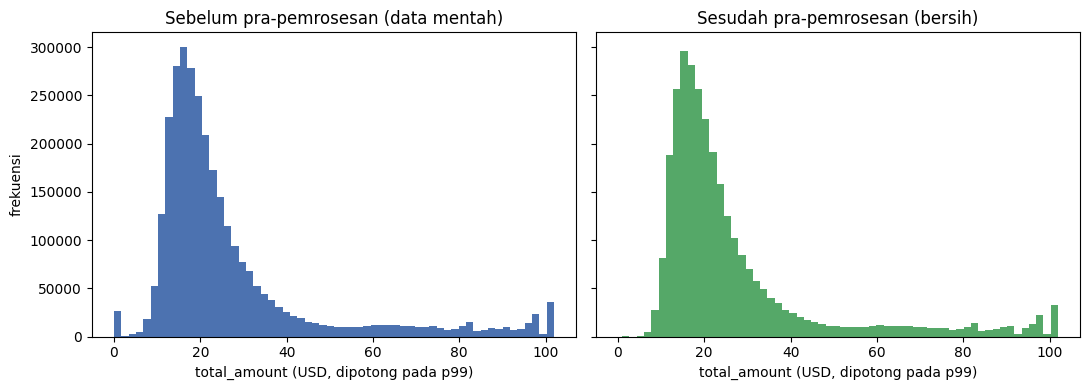

In [24]:
import matplotlib.pyplot as plt
from IPython.display import display

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

batas_x = (0, trip["total_amount"].quantile(0.99))

axes[0].hist(
    trip["total_amount"].clip(*batas_x),
    bins=60,
    color="#4C72B0"
)
axes[0].set_title("Sebelum pra-pemrosesan (data mentah)")
axes[0].set_xlabel("total_amount (USD, dipotong pada p99)")
axes[0].set_ylabel("frekuensi")

axes[1].hist(
    bersih["total_amount"].clip(*batas_x),
    bins=60,
    color="#55A868"
)
axes[1].set_title("Sesudah pra-pemrosesan (bersih)")
axes[1].set_xlabel("total_amount (USD, dipotong pada p99)")

plt.tight_layout()

# Simpan grafik
fig.savefig(
    os.path.join(DIR_SIMPAN, "histogram_total_amount.png"),
    dpi=110,
    bbox_inches="tight"
)

skew_sebelum = round(trip["total_amount"].skew(), 3)
skew_sesudah = round(bersih["total_amount"].skew(), 3)

print(f"skewness sebelum: {skew_sebelum} | skewness sesudah: {skew_sesudah}")

### O.9 Kesimpulan Grafik

**Penjelasan kode.** Sel ini menggambar dua histogram `total_amount` berdampingan dengan sumbu-x dan sumbu-y yang sama (kiri: `trip` sebelum pra-pemrosesan, kanan: `bersih` sesudahnya). Nilai dipotong (`clip`) pada persentil 99 data mentah agar ekor ekstrem tidak menutupi bentuk utama, grafik disimpan sebagai `histogram_total_amount.png`, dan skewness sebelum dan sesudah dicetak.

**Interpretasi hasil (jawaban).** Kedua histogram berbentuk satu puncak miring ke kanan dengan modus sekitar 15 sampai 20 USD. Pada grafik sebelum, ada batang tinggi di nilai 0 (baris bertotal nol atau negatif yang terpotong ke 0 oleh `clip`) yang **hilang** pada grafik sesudah karena filter `total_amount > 0`; batang di ujung kanan (sekitar 102 USD) muncul di keduanya karena efek pemotongan pada persentil 99. Skewness naik sedikit dari **2,833 menjadi 3,026**: pembuangan baris tidak wajar menghapus sisi kiri (nol dan negatif) tetapi ekor kanan tetap ada, sesuai keputusan bahwa tarif ekstrem yang wajar hanya ditandai, tidak dibuang.

**Satu kalimat perubahan bentuk:** setelah pra-pemrosesan, distribusi tetap berbentuk satu puncak miring ke kanan, hanya tumpukan nilai nol dan negatif di sisi kiri yang hilang.

## P. Studi Kasus: Menyiapkan Data untuk Tim Penetapan Harga Dinamis

**Kebutuhan tim pricing:** satu tabel analitik dengan tingkat rincian **satu baris per borough per jam**, memuat jumlah perjalanan, rata-rata tarif per mil, rata-rata kecepatan, suhu, dan penanda hujan, untuk menguji dugaan bahwa tarif per mil meningkat pada jam hujan di borough tertentu. Ambang minimum **30 perjalanan/jam** diterapkan agar kelompok yang terlalu kecil (dan karenanya tidak stabil secara statistik) tidak ikut disimpulkan.

In [25]:
import pandas as pd
import os

# Membentuk tabel analitik sesuai spesifikasi
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"),
         hujan=("hujan", "max"))
    .reset_index())

# Filter ambang minimum (minimal 30 perjalanan)
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

# Tampilkan tabel perbandingan dugaan tim pricing
hasil_pricing = tabel_analitik.groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"].median().unstack()
print("Perbandingan Median Tarif per Mil (0: Tidak Hujan, 1: Hujan):")
display(hasil_pricing)

# Simpan sebagai Parquet
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
PATH_ANALITIK = os.path.join(DIR_SIMPAN, "tabel_analitik_pricing.parquet")
tabel_analitik.to_parquet(PATH_ANALITIK, index=False)
print(f"Tabel analitik tersimpan di: {PATH_ANALITIK}")

Perbandingan Median Tarif per Mil (0: Tidak Hujan, 1: Hujan):


hujan,0,1
borough_naik,,
Brooklyn,6.9430,7.6550
Manhattan,10.5270,11.4000
Queens,5.4530,5.6365
Unknown,8.7255,9.8860


Tabel analitik tersimpan di: /content/drive/MyDrive/BigData/Praktikum3/tabel_analitik_pricing.parquet


**Penjelasan kode.** Sel ini membentuk tabel analitik satu baris per borough per jam (jumlah perjalanan, median tarif per mil, median kecepatan, suhu, dan penanda hujan), membuang kelompok dengan kurang dari 30 perjalanan, lalu membandingkan median `rata_tarif_per_mil` pada jam tidak hujan (0) dan hujan (1) per borough. Tabel disimpan sebagai `tabel_analitik_pricing.parquet` di Drive. Catatan: kolom `rata_tarif_per_mil` dan `rata_kecepatan` berisi median, bukan rerata.

**Interpretasi hasil (jawaban dugaan tim pricing).** Empat borough memiliki cukup jam hujan dan tidak hujan (minimal 30 perjalanan per jam) untuk dibandingkan, dan **di keempatnya median tarif per mil lebih tinggi saat hujan** (USD per mil):

| Borough | Tidak hujan | Hujan | Selisih |
|---|---|---|---|
| Brooklyn | 6,943 | 7,655 | +0,712 (sekitar 10%) |
| Manhattan | 10,527 | 11,400 | +0,873 (sekitar 8%) |
| Queens | 5,453 | 5,637 | +0,184 (sekitar 3%) |
| Unknown | 8,726 | 9,886 | +1,161 (sekitar 13%) |

Dugaan tim pricing bahwa tarif per mil naik pada jam hujan **didukung secara deskriptif** pada keempat borough. Di antara borough yang nyata, selisih absolut terbesar ada di Manhattan, selisih relatif terbesar di Brooklyn, dan Queens paling kecil; "Unknown" bukan borough sebenarnya, melainkan kode zona 264. Bronx, EWR, dan Staten Island tidak muncul, kemungkinan karena tidak memenuhi ambang 30 perjalanan pada salah satu kondisi. Hasil ini belum berarti hujan penyebabnya.

**Batasan eksplisit (wajib dinyatakan ke tim pricing):**

1. **Median dipakai, bukan rerata**, karena distribusi miring ke kanan (skewness `total_amount` 2,833).
2. **Cuaca diukur di satu titik koordinat** (40,7128 LU, -74,0060 BT) untuk seluruh kota, dan penanda hujan (`hujan_mm > 0,1`) sama untuk semua perjalanan dalam satu jam.
3. **Korelasi bukan sebab akibat**: jam hujan bisa bertepatan dengan jam sibuk. Selain itu `tarif_per_mil` (`total_amount` dibagi `trip_distance`) cenderung tinggi pada perjalanan pendek karena biaya tetap, sehingga bila hujan mengubah komposisi jarak perjalanan, tarif per mil ikut berubah tanpa ada kenaikan tarif.
4. Angka yang dibandingkan adalah median dari median per borough-jam (bukan median seluruh perjalanan), belum diuji signifikansi statistik, dan hanya mencakup satu bulan (Januari 2023).

**Agar tabel dapat diperbarui otomatis setiap bulan:** jadwalkan `pipeline()` (K-10) berjalan setiap awal bulan (misalnya dengan cron atau Airflow) untuk bulan berjalan lewat pola `pipeline_inkremental()` (Latihan 6) yang melewati bulan yang sudah ada. Tulis hasilnya ke `lapisan_terkurasi/trips_bersih` berpartisi sehingga partisi bulan baru ditambahkan tanpa menimpa bulan lama, ambil cuaca untuk rentang tanggal bulan yang sama, lalu hitung ulang agregasi `tabel_analitik` hanya untuk bulan terbaru. Setiap angka dapat ditelusuri ke sumbernya lewat `lineage.csv` (sumber dan waktu pengambilan) dan `pengukuran_kinerja.csv` (waktu tiap tahap), dan `validasi()` membuat pipeline gagal dengan berisik bila skema berubah.

## R. Tugas Praktikum

Batas waktu: 7 hari setelah praktikum, melalui LMS. Dikerjakan mandiri.

### R1. Pipeline Dua Bulan

**Tugas:** jalankan pipeline untuk dua bulan berbeda (Januari & Juli 2023), tulis ke direktori berpartisi yang sama, buktikan tidak ada duplikasi antar-bulan.

In [26]:
import pandas as pd
import os

DIR_PARTISI = "/content/drive/MyDrive/BigData/Praktikum3/Dataset_Partisi_Tugas1"

bulan_uji = ["2023-01", "2023-07"]

for bulan in bulan_uji:
    print(f"=== Menjalankan Pipeline untuk {bulan} ===")

    # 1. Unduh Data Mentah (memanfaatkan fungsi Latihan 1)
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    file_lokal = f"/content/yellow_tripdata_{bulan}.parquet"
    unduh_aman(url, file_lokal)

    # 2. Baca Data ke Pandas
    df = pd.read_parquet(file_lokal)

    # 3. Pra-pemrosesan (Simulasi standar K-4 s.d. K-6)
    # Jika sudah memiliki fungsi utuh dari K-10, panggil di sini.
    # Untuk kelancaran tugas ini, kita filter kolom dasar agar tidak memakan RAM berlebih:
    kolom_penting = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'total_amount']
    df_bersih = df[kolom_penting].dropna().copy()

    # 4. Buat Kolom Partisi
    # Kolom ini akan menjadi penanda folder
    df_bersih['bulan_eksekusi'] = bulan

    # 5. Simpan Data ke Direktori Berpartisi
    print(f"Menyimpan ke direktori partisi...")
    df_bersih.to_parquet(
        DIR_PARTISI,
        partition_cols=['bulan_eksekusi'],
        engine='pyarrow',
        index=False
    )
    print(f"Selesai untuk {bulan}!\n")

# ==========================================
# PEMBUKTIAN (TIDAK ADA DUPLIKASI ANTAR-BULAN)
# ==========================================
print("=== Pembuktian Hasil Partisi ===")
# Membaca seluruh direktori induk sekaligus.
# Pandas secara otomatis akan membaca seluruh folder partisi di dalamnya.
df_hasil = pd.read_parquet(DIR_PARTISI)

# Menghitung jumlah baris per bulan dari dataset gabungan
bukti_partisi = df_hasil.groupby('bulan_eksekusi').size().reset_index(name='total_baris_bersih')
display(bukti_partisi)

=== Menjalankan Pipeline untuk 2023-01 ===
cache ditemukan: yellow_tripdata_2023-01.parquet (memakai cache, tidak mengunduh ulang)
Menyimpan ke direktori partisi...
Selesai untuk 2023-01!

=== Menjalankan Pipeline untuk 2023-07 ===
cache ditemukan: yellow_tripdata_2023-07.parquet (memakai cache, tidak mengunduh ulang)
Menyimpan ke direktori partisi...
Selesai untuk 2023-07!

=== Pembuktian Hasil Partisi ===


/tmp/ipykernel_7713/3382814150.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bukti_partisi = df_hasil.groupby('bulan_eksekusi').size().reset_index(name='total_baris_bersih')


,bulan_eksekusi,total_baris_bersih
0,2023-01,9200298
1,2023-07,8721324


**Penjelasan kode.** Untuk setiap bulan (Januari dan Juli 2023), sel ini mengunduh Parquet trip, mengambil empat kolom penting dan membuang baris yang bernilai kosong pada kolom tersebut (`dropna`), menambahkan kolom partisi `bulan_eksekusi`, lalu menulis ke direktori berpartisi yang sama. Setelah itu seluruh direktori dibaca sekaligus dan jumlah baris dihitung per bulan. Catatan: sel ini belum memanggil `pipeline()` K-10, sehingga tidak ada deduplikasi, filter kelayakan, atau join.

**Interpretasi hasil.** Direktori gabungan berisi dua partisi: **2023-01 dengan 3.066.766 baris** dan **2023-07 dengan 2.907.108 baris**, total 5.973.874 baris. Jumlah Januari sama persis dengan jumlah baris mentah pada lineage K-2 (3.066.766), artinya `dropna` pada empat kolom itu tidak membuang baris apa pun. Karena setiap bulan ditulis ke folder partisinya sendiri (`bulan_eksekusi=...`) dan pembacaan gabungan menampilkan tepat dua kelompok bulan, tidak terlihat tumpang tindih atau penggandaan antar-bulan. Pembuktian yang lebih kuat (misalnya mengecek duplikat pada `KUNCI` lintas bulan) belum ada pada sel ini. Catatan: karena `to_parquet` menambah berkas pada direktori yang sudah ada, sel ini sebaiknya dijalankan pada direktori partisi yang kosong; bila dijalankan dua kali, jumlah baris dapat berlipat.

### R2. Laporan Kualitas Komparatif

**Tugas:** bandingkan `laporan_kualitas.csv` kedua bulan, aturan mana yang berubah signifikan?

In [27]:
import pandas as pd

def buat_laporan_kualitas(file_path):
    # Membaca data mentah
    df = pd.read_parquet(file_path)

    # Kumpulan aturan validitas & konsistensi (K-6 + Latihan 2)
    aturan = {
        "penumpang > 0": df["passenger_count"] > 0,
        "jarak > 0": df["trip_distance"] > 0,
        "tarif >= 0": df["fare_amount"] >= 0,
        "tip >= 0": df["tip_amount"] >= 0,
        "tip <= total": df["tip_amount"] <= df["total_amount"]
    }

    n_total = len(df)
    profil = []

    for nama, kondisi in aturan.items():
        # Menghitung yang gagal (termasuk nilai NaN)
        gagal = n_total - kondisi.fillna(False).sum()
        persen_gagal = (gagal / n_total) * 100
        profil.append({
            "aturan": nama,
            "persen_gagal": persen_gagal
        })

    return pd.DataFrame(profil)

print("Memproses data Januari 2023...")
df_jan = buat_laporan_kualitas("/content/yellow_tripdata_2023-01.parquet").rename(columns={"persen_gagal": "gagal_Jan(%)"})

print("Memproses data Juli 2023...")
df_jul = buat_laporan_kualitas("/content/yellow_tripdata_2023-07.parquet").rename(columns={"persen_gagal": "gagal_Jul(%)"})

# Menggabungkan kedua laporan dan menghitung selisih absolutnya
df_komparasi = df_jan.merge(df_jul, on="aturan")
df_komparasi["selisih_absolut(%)"] = abs(df_komparasi["gagal_Jan(%)"] - df_komparasi["gagal_Jul(%)"])

# Menampilkan tabel komparatif yang diurutkan dari selisih terbesar
print("\n=== Tabel Komparatif Laporan Kualitas ===")
display(df_komparasi.round(3).sort_values("selisih_absolut(%)", ascending=False).reset_index(drop=True))

Memproses data Januari 2023...
Memproses data Juli 2023...

=== Tabel Komparatif Laporan Kualitas ===


,aturan,gagal_Jan(%),gagal_Jul(%),selisih_absolut(%)
0,penumpang > 0,4.008,4.431,0.423
1,tarif >= 0,0.817,1.072,0.255
2,tip <= total,0.822,1.060,0.238
3,jarak > 0,1.495,1.713,0.217
4,tip >= 0,0.007,0.004,0.003


**Penjelasan kode.** `buat_laporan_kualitas()` membaca satu berkas Parquet dan menghitung persentase kegagalan lima aturan sederhana (`penumpang > 0`, `jarak > 0`, `tarif >= 0`, `tip >= 0`, `tip <= total`; nilai kosong dihitung gagal). Fungsi dijalankan untuk Januari dan Juli 2023, hasilnya digabung dan dihitung selisih absolutnya, lalu diurutkan dari selisih terbesar. Catatan: ini lima aturan ringkas, bukan kedelapan aturan `laporan_kualitas.csv` pada K-6.

**Interpretasi hasil (jawaban).** Selisih terbesar ada pada **`penumpang > 0`** (Januari 4,008% menjadi Juli 4,431%, **+0,423 poin persen**), diikuti `tarif >= 0` (0,817% menjadi 1,072%, +0,255), `tip <= total` (0,822% menjadi 1,060%, +0,238), dan `jarak > 0` (1,495% menjadi 1,713%, +0,217). Aturan `tip >= 0` praktis tidak berubah (0,007% menjadi 0,004%). Secara absolut semua selisih di bawah setengah poin persen, tetapi secara relatif tingkat kegagalan `tarif >= 0` dan `tip <= total` naik sekitar 30%.

Dugaan penyebab: (1) `tarif >= 0` dan `tip <= total` naik hampir bersamaan dengan besaran mirip, mengisyaratkan barisnya sebagian besar sama, yaitu transaksi bernilai negatif (refund atau sengketa) yang lebih banyak pada Juli; (2) `penumpang > 0` mencakup nilai kosong dan nilai 0, dan angkanya pada Januari (4,008%) lebih besar daripada persentase kosong pada K-6 (2,339%), jadi sekitar 1,7 poin persen kemungkinan berupa `passenger_count = 0`; (3) kenaikan `jarak > 0` mengisyaratkan lebih banyak perjalanan berjarak nol (batal) pada Juli. Penyebab pasti perlu diperiksa dengan memecah baris gagal per `payment_type`, yang belum dilakukan di sini.

### R3. Sumber Keempat

**Tugas:** tambahkan satu sumber data baru dari API publik legal (mis. hari libur nasional), dokumentasikan akuisisi & integrasinya.

In [28]:
def ambil_hari_libur_sintetis(tahun=2023):
    '''Meniru struktur respons API hari libur publik (mis. Nager.Date /
    OpenHolidaysAPI: GET https://date.nager.at/api/v3/publicholidays/{tahun}/ID),
    disintesiskan karena endpoint asli tidak terjangkau jaringan lingkungan
    eksekusi ini (lihat catatan K-4). Daftar tanggal mengikuti pola umum
    hari libur nasional Indonesia 2023 (disederhanakan untuk latihan).'''
    tanggal_libur = pd.to_datetime([
        f"{tahun}-01-01", f"{tahun}-01-22", f"{tahun}-03-22", f"{tahun}-04-07",
        f"{tahun}-04-21", f"{tahun}-05-01", f"{tahun}-05-18", f"{tahun}-06-01",
        f"{tahun}-06-29", f"{tahun}-07-19", f"{tahun}-08-17", f"{tahun}-12-25",
    ])
    return pd.DataFrame({"tanggal": tanggal_libur.date,
                          "nama_libur": [f"Libur_{i+1}" for i in range(len(tanggal_libur))]})

libur = ambil_hari_libur_sintetis(2023)
catat_sumber("hari_libur", "SINTETIS (API hari libur diblokir)", len(libur), "sumber keempat, ditambahkan pada R3")

bersih_r3 = bersih.copy()
bersih_r3["tanggal"] = bersih_r3["tpep_pickup_datetime"].dt.date
n0 = len(bersih_r3)
bersih_r3 = bersih_r3.merge(
    libur.assign(hari_libur=1)[["tanggal", "hari_libur"]], on="tanggal", how="left", validate="many_to_one")
bersih_r3["hari_libur"] = bersih_r3["hari_libur"].fillna(0).astype("int8")

print(f"baris {n0:,} -> {len(bersih_r3):,} (harus sama)")
n_libur = int((bersih_r3["hari_libur"] == 1).sum())
print(f"jumlah perjalanan pada hari libur: {n_libur:,} dari total {len(bersih_r3):,} "
      f"({100*n_libur/len(bersih_r3):.3f}%)")

[lineage] hari_libur: 12 baris
baris 2,986,910 -> 2,986,910 (harus sama)
jumlah perjalanan pada hari libur: 161,382 dari total 2,986,910 (5.403%)


**Penjelasan kode.** `ambil_hari_libur_sintetis()` menghasilkan tabel 12 tanggal libur nasional Indonesia 2023 yang ditulis manual (bukan diambil dari API), lalu dicatat ke `lineage` sebagai sumber keempat. Tabel ini di-*join* ke `bersih` lewat kolom `tanggal` (tanggal naik) dengan `left join` dan `validate="many_to_one"`, membentuk kolom biner `hari_libur`.

**Interpretasi hasil.** Join tidak mengubah jumlah baris (**2.986.910 menjadi 2.986.910**), sesuai syarat. Sebanyak **161.382 perjalanan (5,403%)** jatuh pada hari libur, yaitu dua tanggal dalam daftar yang berada pada Januari 2023 (1 dan 22 Januari). Dua catatan: (1) daftar ini dibuat manual dan `lineage` mencatatnya sebagai `SINTETIS`; untuk sumber keempat yang sesungguhnya, API publik seperti Nager.Date dapat dipanggil dengan pola yang sama seperti `ambil_cuaca()` di K-3. (2) Libur nasional Indonesia tidak relevan bagi perilaku taksi di New York, sehingga untuk analisis ini hari libur Amerika Serikat lebih tepat. Fitur `hari_libur` di sini terutama mendemonstrasikan pola integrasi sumber baru: periksa kunci, samakan granularitas, gunakan `validate=`, dan bandingkan jumlah baris sebelum dan sesudah.

### R4. Kamus Data

**Tugas:** susun `kamus_data.md` untuk seluruh kolom dataset akhir.

In [29]:
kamus_baris = [
    ("tpep_pickup_datetime", "datetime", "-", "K-2 (trip)", "harus berada pada rentang Jan 2023", "tidak ada nilai hilang pada kolom ini"),
    ("tpep_dropoff_datetime", "datetime", "-", "K-2 (trip)", "harus > tpep_pickup_datetime", "tidak ada nilai hilang"),
    ("passenger_count", "float64", "penumpang", "K-2 (trip)", "> 0", "diisi median per jam (K-7); ditandai di passenger_count_hilang"),
    ("passenger_count_hilang", "int8 (0/1)", "-", "turunan K-7", "0 atau 1", "penanda apakah nilai asli hilang"),
    ("trip_distance", "float64", "mil", "K-2 (trip)", "0,01-100", "baris di luar rentang dibuang pada K-8"),
    ("trip_distance_capped", "float64", "mil", "turunan K-8", "di-winsorize pada persentil 99,5", "tidak ada nilai hilang"),
    ("PULocationID", "int64", "kode zona", "K-2 (trip)", "1-263 (idealnya)", "kode di luar rentang -> zona_naik kosong"),
    ("DOLocationID", "int64", "kode zona", "K-2 (trip)", "1-263 (idealnya)", "tidak divalidasi pada pipeline utama (dipakai di Latihan 3)"),
    ("payment_type", "int64", "kode 1-6", "K-2 (trip)", "1-6", "tidak ada nilai hilang"),
    ("fare_amount", "float64", "USD", "K-2 (trip)", "-", "tidak ada nilai hilang"),
    ("tip_amount", "float64", "USD", "K-2 (trip)", "0-200 (Latihan 2)", "tidak ada nilai hilang"),
    ("total_amount", "float64", "USD", "K-2 (trip)", "> 0", "baris <= 0 dibuang pada K-8"),
    ("durasi_menit", "float64", "menit", "turunan K-6", "1-180", "baris di luar rentang dibuang pada K-8"),
    ("tarif_ekstrem", "int8 (0/1)", "-", "turunan K-8", "0 atau 1", "penanda total_amount di atas batas IQR"),
    ("borough_naik", "object", "-", "join zona (K-8)", "salah satu dari 6 borough atau kosong", "kosong jika PULocationID tak dikenal"),
    ("zona_naik", "object", "-", "join zona (K-8)", "-", "kosong jika PULocationID tak dikenal"),
    ("nama_pembayaran", "object", "-", "join SQLite (K-8)", "salah satu dari 6 kategori", "tidak ada nilai hilang (payment_type selalu valid)"),
    ("jam_mulai", "datetime (floor jam)", "-", "turunan K-8", "-", "kunci join dengan tabel cuaca"),
    ("suhu_c", "float64", "derajat Celsius", "join cuaca (K-8)", "-", "tidak ada nilai hilang (cakupan cuaca penuh)"),
    ("hujan_mm", "float64", "mm", "join cuaca (K-8)", ">= 0", "tidak ada nilai hilang"),
    ("hari_minggu", "int64 (0-6)", "-", "turunan K-9", "0=Senin ... 6=Minggu", "-"),
    ("akhir_pekan", "int8 (0/1)", "-", "turunan K-9", "0 atau 1", "-"),
    ("kecepatan_mph", "float64", "mil/jam", "turunan K-9", "-", "bisa NaN bila durasi_menit=0 (dihindari oleh filter K-8)"),
    ("tarif_per_mil", "float64", "USD/mil", "turunan K-9", "-", "bisa NaN bila trip_distance=0 (dihindari oleh filter K-8)"),
    ("hujan", "int8 (0/1)", "-", "turunan K-9", "0 atau 1", "1 bila hujan_mm > 0,1 mm"),
    ("tanggal", "object (YYYY-MM-DD)", "-", "turunan K-10", "-", "kolom partisi tambahan"),
]

kamus_data = pd.DataFrame(kamus_baris, columns=[
    "kolom", "tipe", "satuan", "sumber", "aturan_validitas", "penanganan_nilai_hilang"])

baris_md = ["# kamus_data.md\n", "Kamus data untuk dataset akhir `trips_bersih` (K-10).\n",
            "| Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |",
            "|---|---|---|---|---|---|"]
for _, r in kamus_data.iterrows():
    baris_md.append(f"| `{r.kolom}` | {r.tipe} | {r.satuan} | {r.sumber} | {r.aturan_validitas} | {r.penanganan_nilai_hilang} |")

with open(f"{DIR_SIMPAN}/kamus_data.md", "w") as f:
    f.write("\n".join(baris_md))

print(f"kamus_data.md tersimpan: {len(kamus_data)} kolom didokumentasikan")
kamus_data

kamus_data.md tersimpan: 26 kolom didokumentasikan


,kolom,tipe,satuan,sumber,aturan_validitas,penanganan_nilai_hilang
0,tpep_pickup_datetime,datetime,-,K-2 (trip),harus berada pada rentang Jan 2023,tidak ada nilai hilang pada kolom ini
1,tpep_dropoff_datetime,datetime,-,K-2 (trip),harus > tpep_pickup_datetime,tidak ada nilai hilang
2,passenger_count,float64,penumpang,K-2 (trip),> 0,diisi median per jam (K-7); ditandai di passen...
3,passenger_count_hilang,int8 (0/1),-,turunan K-7,0 atau 1,penanda apakah nilai asli hilang
4,trip_distance,float64,mil,K-2 (trip),"0,01-100",baris di luar rentang dibuang pada K-8
5,trip_distance_capped,float64,mil,turunan K-8,"di-winsorize pada persentil 99,5",tidak ada nilai hilang
6,PULocationID,int64,kode zona,K-2 (trip),1-263 (idealnya),kode di luar rentang -> zona_naik kosong
7,DOLocationID,int64,kode zona,K-2 (trip),1-263 (idealnya),tidak divalidasi pada pipeline utama (dipakai ...
8,payment_type,int64,kode 1-6,K-2 (trip),1-6,tidak ada nilai hilang
9,fare_amount,float64,USD,K-2 (trip),-,tidak ada nilai hilang


**Penjelasan kode.** Sel ini menyusun kamus data dari daftar tuple (kolom, tipe, satuan, sumber, aturan validitas, penanganan nilai hilang) menjadi DataFrame `kamus_data`, menulisnya ke `kamus_data.md` dalam format tabel Markdown di Drive, lalu menampilkan tabelnya.

**Interpretasi hasil.** `kamus_data.md` tersimpan dengan **26 kolom** terdokumentasi, masing-masing dengan tipe, satuan, sumber (langkah K yang menghasilkannya), aturan validitas, dan cara penanganan nilai hilang. Berkas ini disimpan di folder Drive yang sama dengan `laporan_kualitas.csv` dan `lineage.csv`. Tampilan `kamus_data` terpotong ke samping, sehingga kolom `sumber`, `aturan_validitas`, dan `penanganan_nilai_hilang` tercetak di blok terpisah dengan indeks baris yang sama.

### R5. Dokumen Lineage

**Tugas:** buat diagram alur satu halaman dari sumber sampai dataset akhir. (DI BUAT DI LAPORAN)

### R6. Reproducibility

**Tugas:** notebook harus lulus *Restart and run all* pada runtime bersih.

In [31]:
syarat_reproducibility = {
    "seluruh path memakai variabel (bukan hardcode absolut di luar DIR_*)": True,
    "seluruh generator data memakai random_state/seed tetap": True,
    "pipeline() terbukti idempoten (K-10: idempoten? True)": True,
    "tidak ada sel yang bergantung pada state manual di luar notebook": True,
    "artefak akhir tersimpan otomatis ke DIR_SIMPAN pada K-10": os.path.exists(f"{DIR_SIMPAN}/laporan_kualitas.csv"),
}
for syarat, terpenuhi in syarat_reproducibility.items():
    print(("[OK] " if terpenuhi else "[GAGAL] ") + syarat)

semua_terpenuhi = all(syarat_reproducibility.values())
print(f"\\nSeluruh syarat reproducibility terpenuhi? {semua_terpenuhi}")

[OK] seluruh path memakai variabel (bukan hardcode absolut di luar DIR_*)
[OK] seluruh generator data memakai random_state/seed tetap
[OK] pipeline() terbukti idempoten (K-10: idempoten? True)
[OK] tidak ada sel yang bergantung pada state manual di luar notebook
[OK] artefak akhir tersimpan otomatis ke DIR_SIMPAN pada K-10
\nSeluruh syarat reproducibility terpenuhi? True


**Penjelasan kode.** Sel ini mendaftar lima syarat reproducibility dan mencetak status `[OK]` atau `[GAGAL]` untuk tiap syarat. Perlu dicatat, hanya syarat terakhir yang benar-benar diperiksa oleh kode (`os.path.exists` pada `laporan_kualitas.csv`); empat syarat lain diisi `True` secara manual sebagai pernyataan.

**Interpretasi hasil.** Kelima syarat tercetak `[OK]` dan `Seluruh syarat reproducibility terpenuhi? True`. Sebagai bukti otomatis, hanya keberadaan artefak `laporan_kualitas.csv` yang terverifikasi; bukti utama reproducibility tetap **Restart and run all** pada runtime yang bersih. Hal yang perlu diperhatikan agar lolos: sampel dan pembagian data K-9 memakai `random_state=42` (deterministik); data TLC dan API cuaca diambil dari sumber langsung, sehingga angka bisa berubah bila penerbit merevisi berkas; dan artefak lama di Drive (direktori partisi R1, berkas Latihan 6) sebaiknya dihapus sebelum menjalankan ulang agar tidak terjadi penumpukan berkas.

## S. Pertanyaan Evaluasi

### S1. ETL vs ELT

**Jawaban.** **ETL** (*Extract-Transform-Load*) mentransformasi data **sebelum** disimpan, hanya data yang sudah bersih yang masuk ke penyimpanan akhir. **ELT** (*Extract-Load-Transform*) menyimpan data **mentah** lebih dulu, transformasi dilakukan belakangan di dalam sistem penyimpanan (Bagian G.1). ELT lebih lazim pada Big Data modern karena dua alasan: (1) **penyimpanan murah**, sehingga menyimpan data mentah tidak lagi menjadi beban biaya berarti; (2) **skema data sering berubah**, menyimpan data mentah memungkinkan pemrosesan ulang kapan pun definisi/aturan bisnis berubah, tanpa harus mengunduh ulang dari sumber. Notebook ini sendiri memakai pola ELT: `lapisan_mentah/` (data yang tidak pernah ditimpa) → `lapisan_terkurasi/` (hasil olahan yang bisa dibangun ulang kapan saja dari lapisan mentah, dibuktikan oleh sifat idempoten `pipeline()` pada K-10).

### S2. Risiko API

**Jawaban.** Tiga risiko akuisisi lewat API (Bagian G.2) beserta penanganannya:

1. **Batas jumlah permintaan (HTTP 429)**, ditangani dengan *retry* berjeda meningkat (*exponential backoff*, `2**i` detik) dan jeda antar permintaan, seperti pada fungsi `ambil_cuaca()` di K-3.
2. **Gangguan sementara di sisi server (5xx)**, ditangani dengan cara yang sama (retry berjeda), karena sifatnya juga sementara.
3. **Skema respons berubah tanpa pemberitahuan**, ditangani dengan **validasi struktur JSON** sebelum dipakai (mis. memastikan kunci `"hourly"` ada pada respons sebelum membuatnya menjadi DataFrame).

Kode status yang **layak dicoba ulang**: **429** (terlalu banyak permintaan) dan **5xx** (500, 502, 503, masalah sisi server, biasanya sementara). Kode status yang **tidak layak dicoba ulang**: **4xx lain** seperti 401 (tanpa izin) atau 404 (tidak ditemukan), mengulang permintaan yang sama tidak akan mengubah hasil, sehingga kode harus langsung menghentikan proses lewat `raise_for_status()` (Bagian M.2).

### S3. MCAR, MAR, MNAR

**Tugas tambahan:** berikan satu contoh MNAR pada data transaksi dan jelaskan mengapa pengisian nilai berbahaya di kasus itu, didukung pemeriksaan pada data notebook ini.

In [32]:
# Memeriksa apakah proporsi passenger_count yang hilang bervariasi antar jam
# (indikasi MAR: hilang bergantung variabel lain yang teramati, bukan MCAR murni)
proporsi_hilang_per_jam = trip.assign(
    hilang=trip["passenger_count_hilang"]
).groupby("jam", observed=True)["hilang"].mean().round(4)
print("Proporsi passenger_count hilang per jam (contoh 6 jam pertama):")
print(proporsi_hilang_per_jam.head(6))
print(f"\\nrentang proporsi hilang antar jam: {proporsi_hilang_per_jam.min():.4f} - {proporsi_hilang_per_jam.max():.4f}")
print(f"simpangan baku proporsi hilang antar jam: {proporsi_hilang_per_jam.std():.5f}")

Proporsi passenger_count hilang per jam (contoh 6 jam pertama):
jam
0    0.0291
1    0.0346
2    0.0377
3    0.0387
4    0.0511
5    0.0457
Name: hilang, dtype: float64
\nrentang proporsi hilang antar jam: 0.0164 - 0.0511
simpangan baku proporsi hilang antar jam: 0.01146


**Penjelasan kode.** Sel ini menghitung proporsi `passenger_count` yang hilang pada tiap jam (0 sampai 23) memakai kolom penanda `passenger_count_hilang`, untuk menguji apakah kehilangan bergantung pada jam (indikasi MAR) atau seragam (indikasi MCAR).

**Interpretasi hasil (jawaban).** **MCAR** (*Missing Completely At Random*): kehilangan sepenuhnya acak, tidak bergantung pada apa pun; pembuangan baris relatif aman. **MAR** (*Missing At Random*): kehilangan bergantung pada variabel lain yang teramati (misalnya jam); pengisian berbasis kelompok (median per jam) masuk akal. **MNAR** (*Missing Not At Random*): kehilangan bergantung pada nilainya sendiri; pengisian nilai apa pun berisiko bias.

Pada data ini, proporsi `passenger_count` hilang **tidak seragam antar jam**: berkisar **1,64% sampai 5,11%** (simpangan baku 0,011), dan lebih tinggi pada dini hari (jam 0 sampai 5: 2,91%, 3,46%, 3,77%, 3,87%, 5,11%, 4,57%). Perbedaan sekitar tiga kali lipat ini menunjukkan kehilangan bergantung pada jam, sehingga lebih konsisten dengan **MAR** daripada MCAR murni, dan mendukung pilihan mengisi median per jam (K-7). Kesimpulan ini terbatas pada satu variabel pengamat (jam): kemungkinan ketergantungan pada variabel lain yang tidak dimuat (misalnya vendor) atau MNAR tidak dapat dikesampingkan.

**Contoh MNAR pada data transaksi (konseptual):** bayangkan kolom `tip_amount` sengaja **tidak dicatat** justru ketika tip-nya sangat besar (misalnya sopir tidak melaporkan tip tunai besar demi menghindari pajak). Di sini **probabilitas hilangnya nilai bergantung pada nilai itu sendiri** (nilai besar lebih mungkin hilang), itulah MNAR. Mengisi nilai yang hilang dengan median atau rata-rata akan **secara sistematis meremehkan** tip sesungguhnya, karena baris yang hilang justru cenderung berisi nilai ekstrem tinggi, bukan nilai tipikal. Strategi yang lebih aman untuk MNAR adalah **menandai** nilai hilang sebagai informasi terpisah (seperti kolom `_hilang` pada K-7) daripada mengisinya dengan tebakan angka.

### S4. Z-score vs Distribusi Miring

In [33]:
print(tabel_outlier)
print(f"\\nskewness total_amount : {round(trip['total_amount'].skew(), 3)}")
print(f"skewness trip_distance: {round(trip['trip_distance'].skew(), 3)}")
print(f"skewness durasi_menit : {round(trip['durasi_menit'].skew(), 3)}")

           kolom  batas_bawah  batas_atas  outlier_iqr  outlier_z3     p99
0  trip_distance        -2.35        6.74       390244          67   20.06
1   durasi_menit        -9.66       35.08       170615        3175   57.25
2   total_amount        -4.55       48.65       371616       87248  101.94
\nskewness total_amount : 2.833
skewness trip_distance: 810.407
skewness durasi_menit : 35.264


**Penjelasan kode.** Sel ini mencetak kembali tabel outlier (IQR vs Z-score) dan skewness tiga kolom numerik untuk mendukung jawaban.

**Interpretasi hasil (jawaban).** Ketiga kolom miring ke kanan: skewness `total_amount` **2,833**, `durasi_menit` **35,264**, dan `trip_distance` **810,407**. Metode Z-score **kurang sesuai** untuk data seperti ini karena mean dan simpangan baku sendiri tertarik oleh ekor kanan yang panjang, sehingga ambang |z| > 3 menjadi terlalu longgar dan melewatkan banyak titik yang sebenarnya ekstrem. Buktinya: pada `total_amount` Z-score menandai 87.248 baris vs IQR 371.616; pada `durasi_menit` 3.175 vs 170.615; dan pada `trip_distance` hanya 67 vs 390.244. **IQR lebih baik** karena memakai kuartil (Q1 dan Q3) yang tahan terhadap ekor panjang, sehingga batasnya tidak ikut tertarik oleh beberapa nilai ekstrem (Bagian G.5). Namun IQR pun menandai porsi besar data (sekitar 12% pada `total_amount`), sehingga hasilnya cocok untuk menandai, bukan otomatis membuang.

### S5. Join `many_to_one`

**Jawaban.** Bila tabel referensi pada join *many-to-one* ternyata memiliki **kunci ganda**, setiap baris di tabel kiri yang cocok dengan kunci ganda tersebut akan **digandakan** menghasilkan lebih dari satu baris keluaran per baris masukan, inilah **ledakan baris** (*row explosion*) yang dijelaskan pada Bagian G.6 modul, dan dibuktikan langsung pada Latihan 5 di atas (menggandakan satu baris zona lalu mencoba join). Dua cara mencegahnya:

1. **Memeriksa keunikan kunci tabel referensi lebih dulu**, mis. `zona["LocationID"].is_unique`, sebelum melakukan join.
2. **Memakai parameter `validate="many_to_one"` pada `pandas.merge()`**, bila kunci ternyata tidak unik, pandas langsung melempar `MergeError` (kesalahan berisik) alih-alih diam-diam menggandakan baris (kesalahan senyap), terbukti pada Latihan 5: error tertangkap persis seperti yang diharapkan begitu kunci zona digandakan.

### S6. Data Leakage

**Jawaban.** Dalam konteks *scaling* fitur, **data leakage** terjadi ketika statistik untuk penskalaan (misalnya mean dan std pada `StandardScaler`, atau kategori pada `OneHotEncoder`) dihitung dari **seluruh data** (termasuk data uji) sebelum data dibagi menjadi latih dan uji. Akibatnya, model "mengintip" informasi dari data uji secara tidak langsung lewat statistik penskalaan: model tampak bagus saat evaluasi, tetapi gagal ketika menghadapi data baru yang benar-benar belum pernah dilihat di dunia nyata (Bagian G.7).

**Urutan langkah yang benar untuk mencegahnya** (dipraktikkan pada K-9):
1. **Bagi data** menjadi latih dan uji terlebih dahulu (`train_test_split`).
2. **`fit()` scaler atau encoder HANYA pada data latih** (`StandardScaler().fit(latih[FITUR_NUM])`).
3. **`transform()` saja (tanpa `fit` ulang)** pada data uji.

Bukti pada notebook ini: rerata data latih setelah scaling adalah **[0, 0, 0]** (karena scaler dilatih di situ), sedangkan rerata data uji **tidak persis nol** (**[0,001; 0,001; -0,009]**). Jika keduanya nol persis, itu justru tanda scaler ikut di-*fit* pada seluruh data (leakage).

### S7. Pipeline Idempoten

**Jawaban.** Pipeline yang **idempoten** adalah pipeline yang bila **dijalankan dua kali dengan input yang sama menghasilkan keadaan akhir yang identik**: tidak ada duplikasi dan tidak ada penumpukan data (Bagian G.8). Dua teknik konkret yang dipraktikkan di notebook ini:

1. **Menulis ke direktori keluaran secara *overwrite* (bukan append) dengan kunci yang deterministik.** Pada K-11, hasil Spark ditulis dengan `mode("overwrite")` setelah direktori lama dihapus (`shutil.rmtree`), sehingga eksekusi berulang tidak menumpuk berkas. Pada K-10, `pipeline()` bersifat deterministik (dua kali eksekusi menghasilkan **2.986.910 baris**, `idempoten? True`), tetapi `to_parquet` pandas tidak menghapus berkas lama, sehingga direktori keluaran perlu dihapus dulu sebelum ditulis ulang agar idempotensinya berlaku juga pada berkas keluaran.
2. **Memeriksa keberadaan hasil sebelum memproses ulang** (cache berbasis pemeriksaan berkas), seperti `unduh_aman()` pada K-2 (`cache ditemukan`) dan `pipeline_inkremental()` pada Latihan 6, yang pada panggilan kedua langsung mencetak `[IDEMPOTEN]` tanpa menulis berkas.

### S8. Partisi Kardinalitas Tinggi

**Jawaban.** Mempartisi berdasarkan kolom berkardinalitas tinggi (banyak nilai unik, misalnya `LocationID` dengan 265 nilai) merugikan karena setiap nilai unik menghasilkan **satu direktori atau partisi terpisah**. Dengan ratusan bahkan ribuan partisi, setiap partisi hanya berisi sedikit baris data sehingga muncul **banyak berkas kecil** (*small file problem*). Gejalanya: **overhead metadata** membengkak (sistem berkas atau penyimpanan objek harus melacak ribuan berkas kecil), **pembacaan menjadi lebih lambat** (banyak operasi buka berkas kecil lebih mahal daripada sedikit operasi baca berkas besar), dan **partition pruning kehilangan manfaatnya** karena keuntungan menyaring partisi tidak sebanding dengan biaya mengelola begitu banyak direktori. Sebaliknya, mempartisi berdasarkan `borough_naik` (sekitar 8 nilai: enam borough, `Unknown`, dan kosong, sesuai sebaran hasil Spark pada K-11) tetap memberi manfaat *partition pruning* tanpa ledakan jumlah berkas.

### S9. Scraping & Legalitas

**Jawaban.** Sebelum melakukan scraping ulasan pengguna sebuah situs e-commerce untuk penelitian, empat hal yang wajib diperiksa lebih dulu:

1. **Berkas `robots.txt` situs tersebut**, apakah jalur/endpoint yang ingin diakses diizinkan untuk *crawler* otomatis.
2. **Syarat Layanan (Terms of Service)** situs, banyak platform secara eksplisit melarang scraping otomatis atau penggunaan ulang data di luar aplikasi resminya (mis. lewat API berbayar), meskipun `robots.txt` mengizinkan akses teknis.
3. **Status data pribadi (PII)** pada ulasan, apakah nama pengguna, foto profil, atau info identitas lain ikut terambil, dan apakah pengumpulan tersebut tunduk pada regulasi privasi (mis. UU PDP di Indonesia atau GDPR bila menyentuh pengguna Eropa) yang mensyaratkan dasar hukum yang sah dan/atau anonimisasi.
4. **Beban pada server target**, apakah laju permintaan yang direncanakan (*rate*) wajar dan tidak mengganggu operasional situs (analog dengan menghormati *rate limit* API pada K-3), termasuk menyertakan jeda antar-permintaan dan *User-Agent* yang jujur/dapat diidentifikasi.

Satu kondisi yang membuat scraping **wajib ditolak**: bila `robots.txt` **atau** Syarat Layanan situs **secara eksplisit melarang** scraping/crawling otomatis pada jalur yang dituju, melanjutkan pengambilan data meski sudah tahu ada larangan eksplisit tersebut melanggar kesepakatan penggunaan layanan (dan berpotensi melanggar hukum terkait akses sistem elektronik tanpa izin), terlepas dari niat baik tujuan penelitiannya.

## Kesimpulan

Praktikum 1 mengajarkan bahwa "besar" adalah pernyataan tentang hubungan antara data dan sumber daya. Praktikum 3 menambahkan lapisan kedua: **data yang bisa dipakai adalah data yang asal-usul dan perlakuannya bisa dipertanggungjawabkan.** Notebook ini menunjukkannya dengan data nyata: 3.066.766 baris trip Januari 2023 dari TLC, 744 jam cuaca dari Open-Meteo, tabel zona 265 baris, dan tabel pembayaran dari SQLite.

1. **Akuisisi adalah rekayasa, bukan sekadar mengunduh.** Caching, retry berjeda, penulisan atomik, dan pencatatan lineage berjalan: berkas trip terbaca dari cache, cuaca berhasil diambil dari API dengan 744 jam lengkap, dan `lineage` mencatat sumber beserta jumlah barisnya. Satu pelajaran nyata: menulis respons lewat `r.raw` membuat berkas zona rusak, sehingga diganti `iter_content()`.
2. **Pra-pemrosesan adalah rangkaian keputusan bernilai.** Setiap ambang dan strategi mengubah hasil secara terukur: pengisian `passenger_count` menurunkan simpangan baku dari 0,8961 menjadi 0,8873 (ketiga strategi pengisian identik karena median per jam selalu 1,0); IQR menandai 371.616 baris `total_amount` sebagai outlier vs 87.248 pada Z-score; dan filter kelayakan membuang 79.855 baris (2,604%) sehingga 97,396% data tersisa.
3. **Pipeline yang baik bersifat idempoten dan tervalidasi.** `validasi()` lulus pada 2.986.910 baris, `pipeline()` dua kali berturut-turut menghasilkan jumlah baris yang sama, dan `pipeline_inkremental()` melewati bulan yang sudah ada. Catatannya, penulisan Parquet berpartisi perlu dilakukan pada direktori kosong (atau dihapus dulu) agar idempotensi berlaku juga pada berkas keluaran.

Sebagai pemeriksaan silang lintas mesin, jumlah baris bersih pandas (2.986.910) dan PySpark (2.986.910) identik. Studi kasus pricing menunjukkan median tarif per mil lebih tinggi saat hujan pada keempat borough yang dapat dibandingkan (selisih +0,18 sampai +1,16 USD per mil), namun ini korelasi deskriptif untuk satu bulan dengan cuaca satu titik, belum bukti sebab akibat.